I. Introduction

Background:

The marketing team at Berlian Bank is looking to segment their credit card users based on transaction data from the past six months. This customer segmentation will help the marketing team better understand credit card user behavior and enable them to deliver targeted promotions and reward systems tailored to each customer segment.

Objective:

The objective of this program is to cluster existing credit card users at Berlian Bank based on their transaction behavior over the past six months, and to provide actionable recommendations to the marketing team on how to approach each customer segment for promotions and offers. Additionally, this analysis aims to provide insights into whether a customer's tenure influences their purchase habits, credit balance, and payment behavior. Lastly, the analysis will also explore whether a higher credit limit affects a customer's purchase frequency.

The techniques used in this model are as follows:

1. PCA (Principal Component Analysis), to reduce the dimensionality of the data by combining features with strong correlations. This is applied prior to clustering. The metrics used to determine the optimal number of components are the variance ratio and eigenvalue.

2. Clustering, to divide the data into groups based on shared characteristics, enabling the marketing team to make informed decisions for each customer segment. K-Means is used as the clustering algorithm given that all features are numerical. Three methods are used to determine the optimal number of clusters: the Elbow Method, Silhouette Score, and Silhouette Plot. Key metrics include WCSS value, k-value, and Silhouette Score.

Scenario / Specific Objective:

The marketing team would like to determine which cluster a given customer (from the inference data) belongs to, and receive guidance on how to best approach that customer for future promotions and offers.


II. Query SQL

Below are the query code line used to retrieve the data for this model (using google collab).

In [1]:
# from google.colab import auth
# from google.cloud import bigquery
# import pandas as pd

# auth.authenticate_user()

# project_id = "dsml-485108" 
# client = bigquery.Client(project=project_id)

# query = """
# SELECT * FROM `ftds-hacktiv8-project.phase1_ftds_052_rmt.credit-card-information`
# WHERE MOD(CUST_ID, 2) = 0
# """

# # retrieve data from query and convert it into dataframe
# df = client.query(query).to_dataframe()

# # save to csv
# df.to_csv('P1G6_devina_agustina.csv', index=False)

III. Import Libraries

The imported libraries would be used in section III to XI.

In [2]:
# Import library
%pip install kmodes yellowbrick
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import warnings
from scipy import stats
from scipy.stats import spearmanr, pearsonr, f_oneway
warnings.filterwarnings('ignore') #turn off warning
from sklearn.preprocessing import OneHotEncoder
from feature_engine.outliers import Winsorizer

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pickle
import json
import dill
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.cm as cm
from sklearn.metrics import silhouette_score,silhouette_samples
from yellowbrick.cluster import SilhouetteVisualizer
from kmodes.kprototypes import KPrototypes
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances


Note: you may need to restart the kernel to use updated packages.


IV. Data Loading

Import the dataset from the source and then make a copy of the original dataset to make sure the original data set is not changed.

In [ ]:
#Loading data original
df_ori = pd.read_csv('../data/raw_data.csv',delimiter=',')
df_ori

#Making data copy for data cleaning for EDA
df_uncleaned = df_ori.copy()
df_uncleaned

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,4004,926.341558,0.909091,45.65,45.65,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1000.0,1293.650192,9957.742740,0.000000,12
1,774,80.336636,0.600000,330.00,330.00,0.00,0.000000,0.100000,0.100000,0.000000,0.000000,0,1,1800.0,345.330572,85.297166,0.000000,10
2,2878,14.074548,1.000000,39.00,0.00,39.00,0.000000,0.166667,0.000000,0.166667,0.000000,0,2,1500.0,98.947093,74.147879,0.000000,12
3,7494,241.223955,0.909091,180.91,180.91,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,6,1400.0,802.858576,220.455533,0.000000,12
4,1908,13.362018,0.363636,119.46,60.27,59.19,0.000000,0.250000,0.166667,0.083333,0.000000,0,4,7500.0,534.740352,132.441551,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4470,3856,5561.390014,1.000000,0.00,0.00,0.00,3041.330064,0.000000,0.000000,0.000000,0.500000,17,0,6000.0,2193.974270,1558.552940,0.000000,12
4471,5308,1219.143484,0.666667,0.00,0.00,0.00,1893.219765,0.000000,0.000000,0.000000,0.500000,3,0,2000.0,204.789406,274.065414,0.000000,6
4472,94,5861.100691,1.000000,64.71,64.71,0.00,9799.529884,0.083333,0.083333,0.000000,0.583333,35,2,9000.0,7371.459399,2791.366849,0.083333,12
4473,8694,1432.326731,0.625000,0.00,0.00,0.00,3771.115165,0.000000,0.000000,0.000000,0.625000,15,0,5000.0,138.855523,531.199840,0.000000,8


Now, we display the first 10 data in the dataframe.

In [4]:
#first 10 data in df
df_uncleaned.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,4004,926.341558,0.909091,45.65,45.65,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,1000.0,1293.650192,9957.742740,0.000000,12
1,774,80.336636,0.600000,330.00,330.00,0.00,0.0,0.100000,0.100000,0.000000,0.0,0,1,1800.0,345.330572,85.297166,0.000000,10
2,2878,14.074548,1.000000,39.00,0.00,39.00,0.0,0.166667,0.000000,0.166667,0.0,0,2,1500.0,98.947093,74.147879,0.000000,12
3,7494,241.223955,0.909091,180.91,180.91,0.00,0.0,0.166667,0.166667,0.000000,0.0,0,6,1400.0,802.858576,220.455533,0.000000,12
4,1908,13.362018,0.363636,119.46,60.27,59.19,0.0,0.250000,0.166667,0.083333,0.0,0,4,7500.0,534.740352,132.441551,0.000000,12
5,5588,242.161751,1.000000,686.00,686.00,0.00,0.0,0.250000,0.250000,0.000000,0.0,0,5,1600.0,79.554524,142.159120,0.000000,12
6,6294,768.881695,0.727273,408.59,408.59,0.00,0.0,0.250000,0.250000,0.000000,0.0,0,7,2500.0,2095.952073,250.856639,0.125000,12
7,1366,6.793588,0.363636,2634.37,1773.40,860.97,0.0,0.333333,0.333333,0.333333,0.0,0,24,4000.0,4144.707044,49.647266,0.000000,12
8,7726,131.271213,1.000000,147.26,0.00,147.26,0.0,0.333333,0.000000,0.250000,0.0,0,4,1000.0,430.455738,163.227325,0.090909,12
9,2182,7.388588,0.545455,84.05,0.00,84.05,0.0,0.416667,0.000000,0.416667,0.0,0,5,4000.0,171.883336,99.694319,0.200000,12


Now, we display the last 10 data in the dataframe.

In [5]:
#first 10 data in df
df_uncleaned.tail(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
4465,3804,1190.884428,0.857143,0.00,0.00,0.00,1817.843113,0.000000,0.000000,0.000000,0.285714,2,0,2000.0,290.690807,251.393985,0.000000,7
4466,5186,738.956988,1.000000,0.00,0.00,0.00,1561.133958,0.000000,0.000000,0.000000,0.333333,6,0,1500.0,1979.193103,198.854631,0.100000,12
4467,3002,409.592245,1.000000,190.00,190.00,0.00,1986.427611,0.166667,0.166667,0.000000,0.333333,6,2,11500.0,299.915950,173.798807,0.000000,12
4468,8756,1428.265873,1.000000,1490.63,1411.88,78.75,5411.208676,0.416667,0.333333,0.166667,0.333333,10,19,5250.0,4644.297034,456.049907,0.166667,12
4469,232,6744.845686,1.000000,4.44,0.00,4.44,19862.878440,0.250000,0.000000,0.166667,0.416667,11,3,16500.0,21440.298660,1350.823356,0.100000,12
4470,3856,5561.390014,1.000000,0.00,0.00,0.00,3041.330064,0.000000,0.000000,0.000000,0.500000,17,0,6000.0,2193.974270,1558.552940,0.000000,12
4471,5308,1219.143484,0.666667,0.00,0.00,0.00,1893.219765,0.000000,0.000000,0.000000,0.500000,3,0,2000.0,204.789406,274.065414,0.000000,6
4472,94,5861.100691,1.000000,64.71,64.71,0.00,9799.529884,0.083333,0.083333,0.000000,0.583333,35,2,9000.0,7371.459399,2791.366849,0.083333,12
4473,8694,1432.326731,0.625000,0.00,0.00,0.00,3771.115165,0.000000,0.000000,0.000000,0.625000,15,0,5000.0,138.855523,531.199840,0.000000,8
4474,1450,4785.789559,1.000000,0.00,0.00,0.00,8422.554694,0.000000,0.000000,0.000000,0.875000,25,0,9500.0,687.474829,1010.781349,0.000000,8


In [6]:
df_uncleaned.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [7]:
""""
To see the column name, non-null count, and data type info in the data frame
"""
#Explore dataset 1
df_uncleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4475 entries, 0 to 4474
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           4475 non-null   int64  
 1   BALANCE                           4475 non-null   float64
 2   BALANCE_FREQUENCY                 4475 non-null   float64
 3   PURCHASES                         4475 non-null   float64
 4   ONEOFF_PURCHASES                  4475 non-null   float64
 5   INSTALLMENTS_PURCHASES            4475 non-null   float64
 6   CASH_ADVANCE                      4475 non-null   float64
 7   PURCHASES_FREQUENCY               4475 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        4475 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  4475 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            4475 non-null   float64
 11  CASH_ADVANCE_TRX                  4475 non-null   int64  
 12  PURCHA

In [8]:
df_uncleaned.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    158
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Based on the information above, only two columns contain null values: 'CREDIT_LIMIT' and 'MINIMUM_PAYMENTS'. This is evident from the non-null counts, where 'CREDIT_LIMIT' has 4,474 non-null entries and 'MINIMUM_PAYMENTS' has 4,317 non-null entries, both falling short of the total 4,475 entries. From the null value summary, 'CREDIT_LIMIT' has 1 null value while 'MINIMUM_PAYMENTS' has 158 null values. These will be addressed in the feature engineering section.As for data types, all columns are already in the appropriate format and do not require any changes. All features in this dataset are numerical.

In [9]:
df_uncleaned.nunique()

CUST_ID                             4475
BALANCE                             4439
BALANCE_FREQUENCY                     42
PURCHASES                           3218
ONEOFF_PURCHASES                    2073
INSTALLMENTS_PURCHASES              2357
CASH_ADVANCE                        2155
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            44
PURCHASES_INSTALLMENTS_FREQUENCY      47
CASH_ADVANCE_FREQUENCY                46
CASH_ADVANCE_TRX                      55
PURCHASES_TRX                        147
CREDIT_LIMIT                         153
PAYMENTS                            4350
MINIMUM_PAYMENTS                    4317
PRC_FULL_PAYMENT                      47
TENURE                                 7
dtype: int64

The results above display the number of unique values in each column, providing a general overview of the data and highlighting columns that may have the potential to be treated as categorical. Notable columns with this potential include BALANCE_FREQUENCY, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PRC_FULL_PAYMENT, and TENURE.

In [10]:
"""
This is to extract the unique value in column BALANCE_FREQUENCY, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX,PRC_FULL_PAYMENT,TENURE
to see whether the value has some similarity or are categorical.
"""
column_info = ['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX' , 'PRC_FULL_PAYMENT' , 'TENURE']
for i in column_info:
    print(f"{i} {df_uncleaned[i].unique()}")
    print(f"Number of unique column: {i} --> {df_uncleaned[i].nunique()}")
    print()

BALANCE_FREQUENCY [0.909091 0.6      1.       0.363636 0.727273 0.545455 0.454545 0.818182
 0.636364 0.9      0.555556 0.666667 0.875    0.833333 0.181818 0.714286
 0.272727 0.625    0.888889 0.857143 0.090909 0.       0.8      0.444444
 0.166667 0.375    0.3      0.333333 0.125    0.7      0.1      0.777778
 0.5      0.571429 0.25     0.75     0.2      0.4      0.285714 0.111111
 0.142857 0.222222]
Number of unique column: BALANCE_FREQUENCY --> 42

PURCHASES_FREQUENCY [0.083333 0.1      0.166667 0.25     0.333333 0.416667 0.5      0.583333
 0.666667 0.75     0.833333 0.916667 1.       0.       0.454545 0.714286
 0.444444 0.857143 0.888889 0.8      0.555556 0.3      0.4      0.818182
 0.9      0.090909 0.272727 0.428571 0.181818 0.909091 0.125    0.142857
 0.625    0.363636 0.571429 0.2      0.727273 0.6      0.545455 0.875
 0.7      0.111111 0.636364 0.375    0.285714 0.777778 0.222222]
Number of unique column: PURCHASES_FREQUENCY --> 47

ONEOFF_PURCHASES_FREQUENCY [0.083333 0.1      

From the results above, there appears to be a similarity between PURCHASES_FREQUENCY and ONEOFF_PURCHASES_FREQUENCY. However, this will be further examined in the Feature Engineering section to confirm. As for the TENURE column, it is evident that this column contains ordinal values and will also be addressed in the Feature Engineering section.

Now, the column name needs to be checked and cleaned to ensure the data is clean and proper.

In [11]:
""""
To see all column names in the data frame
"""
df_uncleaned.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [12]:
"""
To rename the column
"""
df_uncleaned = df_uncleaned.rename(columns={
	'CUST_ID': 'Customer ID', 
	'BALANCE': 'Balance', 
	'BALANCE_FREQUENCY': 'Balance Frequency', 
	'PURCHASES': 'Purchases',
    'ONEOFF_PURCHASES': 'One-off Purchases', 
	'INSTALLMENTS_PURCHASES': 'Installments Purchases', 
	'CASH_ADVANCE': 'Cash Advance',
    'PURCHASES_FREQUENCY': 'Purchases Frequency', 
	'ONEOFF_PURCHASES_FREQUENCY': 'One-off Purchases Frequency',
    'PURCHASES_INSTALLMENTS_FREQUENCY': 'Purchases Installments Frequency', 
	'CASH_ADVANCE_FREQUENCY': 'Cash Advance Frequency',
    'CASH_ADVANCE_TRX': 'Cash Advance Transaction', 
	'PURCHASES_TRX': 'Purchases Transaction', 
	'CREDIT_LIMIT': 'Credit Limit', 
	'PAYMENTS': 'Payments',
    'MINIMUM_PAYMENTS': 'Minimum Payments', 
	'PRC_FULL_PAYMENT': 'Full Payment Percentage', 
	'TENURE': 'Tenure'
	   })
df_uncleaned.head()

,Customer ID,Balance,Balance Frequency,Purchases,One-off Purchases,Installments Purchases,Cash Advance,Purchases Frequency,One-off Purchases Frequency,Purchases Installments Frequency,Cash Advance Frequency,Cash Advance Transaction,Purchases Transaction,Credit Limit,Payments,Minimum Payments,Full Payment Percentage,Tenure
0,4004,926.341558,0.909091,45.65,45.65,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,1000.0,1293.650192,9957.742740,0.0,12
1,774,80.336636,0.600000,330.00,330.00,0.00,0.0,0.100000,0.100000,0.000000,0.0,0,1,1800.0,345.330572,85.297166,0.0,10
2,2878,14.074548,1.000000,39.00,0.00,39.00,0.0,0.166667,0.000000,0.166667,0.0,0,2,1500.0,98.947093,74.147879,0.0,12
3,7494,241.223955,0.909091,180.91,180.91,0.00,0.0,0.166667,0.166667,0.000000,0.0,0,6,1400.0,802.858576,220.455533,0.0,12
4,1908,13.362018,0.363636,119.46,60.27,59.19,0.0,0.250000,0.166667,0.083333,0.0,0,4,7500.0,534.740352,132.441551,0.0,12


Then, we need to check if there is duplicated data or not.

In [13]:
df_uncleaned.duplicated().sum()

0

As shown above, no duplicate entries were found in the dataset, therefore no rows need to be removed. The cleaned data will be stored in a new DataFrame for use in the subsequent steps.

In [14]:
df_cleaned = df_uncleaned.copy()
df_cleaned.head()

,Customer ID,Balance,Balance Frequency,Purchases,One-off Purchases,Installments Purchases,Cash Advance,Purchases Frequency,One-off Purchases Frequency,Purchases Installments Frequency,Cash Advance Frequency,Cash Advance Transaction,Purchases Transaction,Credit Limit,Payments,Minimum Payments,Full Payment Percentage,Tenure
0,4004,926.341558,0.909091,45.65,45.65,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,1000.0,1293.650192,9957.742740,0.0,12
1,774,80.336636,0.600000,330.00,330.00,0.00,0.0,0.100000,0.100000,0.000000,0.0,0,1,1800.0,345.330572,85.297166,0.0,10
2,2878,14.074548,1.000000,39.00,0.00,39.00,0.0,0.166667,0.000000,0.166667,0.0,0,2,1500.0,98.947093,74.147879,0.0,12
3,7494,241.223955,0.909091,180.91,180.91,0.00,0.0,0.166667,0.166667,0.000000,0.0,0,6,1400.0,802.858576,220.455533,0.0,12
4,1908,13.362018,0.363636,119.46,60.27,59.19,0.0,0.250000,0.166667,0.083333,0.0,0,4,7500.0,534.740352,132.441551,0.0,12


As seen from the result above, all is well and now we can move on to the EDA.

V. Exploratory Data Analysis (EDA)

First, we need to describe the numerical data that we have.

In [15]:
df_cleaned.describe()

,Customer ID,Balance,Balance Frequency,Purchases,One-off Purchases,Installments Purchases,Cash Advance,Purchases Frequency,One-off Purchases Frequency,Purchases Installments Frequency,Cash Advance Frequency,Cash Advance Transaction,Purchases Transaction,Credit Limit,Payments,Minimum Payments,Full Payment Percentage,Tenure
count,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4474.000000,4475.000000,4317.000000,4475.000000,4475.000000
mean,4476.000000,1565.743939,0.877608,1003.158324,588.504849,415.025075,973.453671,0.490122,0.202614,0.364989,0.134156,3.196425,14.490503,4494.020175,1726.212274,854.429538,0.157206,11.516425
std,2583.931114,2091.205727,0.235604,2210.812899,1666.500287,927.360842,2133.464502,0.399874,0.298502,0.397336,0.199221,6.500169,24.156038,3668.535689,2961.258570,2306.411178,0.295869,1.347819
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,0.037744,0.000000,6.000000
25%,2239.000000,132.536353,0.888889,40.065000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1500.000000,390.206371,169.814310,0.000000,12.000000
50%,4476.000000,874.905296,1.000000,362.480000,29.990000,89.450000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,831.048408,309.854995,0.000000,12.000000
75%,6713.000000,2058.519163,1.000000,1122.640000,580.320000,484.255000,1098.569962,0.916667,0.333333,0.750000,0.181818,4.000000,17.000000,6000.000000,1895.959003,830.395060,0.166667,12.000000
max,8950.000000,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,29282.109150,1.000000,1.000000,1.000000,1.166667,110.000000,358.000000,30000.000000,46930.598240,61031.618600,1.000000,12.000000


In [16]:
df_cleaned.columns

Index(['Customer ID', 'Balance', 'Balance Frequency', 'Purchases',
       'One-off Purchases', 'Installments Purchases', 'Cash Advance',
       'Purchases Frequency', 'One-off Purchases Frequency',
       'Purchases Installments Frequency', 'Cash Advance Frequency',
       'Cash Advance Transaction', 'Purchases Transaction', 'Credit Limit',
       'Payments', 'Minimum Payments', 'Full Payment Percentage', 'Tenure'],
      dtype='object')

Then, we can analyze all the numerical value except for 'Customer ID' to see the skewness, variance, and kurtosis of the data.

In [17]:
"""
Analyze all the numerical column except for 'Customer ID' with aggregate 'mean', 'median', 'std', 'skew', 'kurtosis', 'var'. The exception for 'Customer ID' is because they do not represent specific value, but instead only
serve as an infomation to identify the customer.
"""
df_cleaned.agg({
	'Balance': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'], 
	'Balance Frequency': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'], 
	'Purchases': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'One-off Purchases': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'], 
	'Installments Purchases': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'], 
	'Cash Advance': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Purchases Frequency': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'], 
	'One-off Purchases Frequency': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Purchases Installments Frequency': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'], 
	'Cash Advance Frequency': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Cash Advance Transaction': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'], 
	'Purchases Transaction': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'], 
	'Credit Limit': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'],
    'Payments': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'], 
	'Minimum Payments': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'], 
	'Full Payment Percentage': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var'], 
	'Tenure': ['mean', 'median', 'std', 'skew', 'kurtosis', 'var']
})

,Balance,Balance Frequency,Purchases,One-off Purchases,Installments Purchases,Cash Advance,Purchases Frequency,One-off Purchases Frequency,Purchases Installments Frequency,Cash Advance Frequency,Cash Advance Transaction,Purchases Transaction,Credit Limit,Payments,Minimum Payments,Full Payment Percentage,Tenure
mean,1.565744e+03,0.877608,1.003158e+03,5.885048e+02,415.025075,9.734537e+02,0.490122,0.202614,0.364989,0.134156,3.196425,14.490503,4.494020e+03,1.726212e+03,8.544295e+02,0.157206,11.516425
median,8.749053e+02,1.000000,3.624800e+02,2.999000e+01,89.450000,0.000000e+00,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3.000000e+03,8.310484e+02,3.098550e+02,0.000000,12.000000
std,2.091206e+03,0.235604,2.210813e+03,1.666500e+03,927.360842,2.133465e+03,0.399874,0.298502,0.397336,0.199221,6.500169,24.156038,3.668536e+03,2.961259e+03,2.306411e+03,0.295869,1.347819
skew,2.456621e+00,-2.020309,8.987052e+00,1.014006e+01,8.116887,4.739678e+00,0.061598,1.523455,0.510288,1.823380,4.752780,4.480452,1.545078e+00,6.040773e+00,1.235786e+01,1.911650,-2.932822
kurtosis,8.157615e+00,3.088315,1.303019e+02,1.644304e+02,121.580108,3.499312e+01,-1.628424,1.128050,-1.393571,3.195777,39.415349,32.147714,2.892369e+00,5.461944e+01,2.229365e+02,2.296432,7.589712
var,4.373141e+06,0.055509,4.887694e+06,2.777223e+06,859998.130993,4.551671e+06,0.159899,0.089103,0.157876,0.039689,42.252200,583.514159,1.345815e+07,8.769052e+06,5.319533e+06,0.087539,1.816617


From the results above, we can conduct a descriptive analysis of the data distribution based on skewness and kurtosis values.Regarding skewness, the columns 'Purchases Frequency' and 'Purchases Installments Frequency' have skewness values within the range of -0.5 to 0.5, indicating a symmetric distribution where the mean and median are similar or near identical. The columns 'Balance', 'Purchases', 'One-off Purchases', 'Installments Purchases', 
'Cash Advance', 'One-off Purchases Frequency', 'Cash Advance Frequency', 'Cash Advance Transaction', 'Purchases Transaction', 'Credit Limit', 'Payments', 'Minimum Payments', and 'Full Payment Percentage' exhibit positive skewness (> 1), meaning the mean is greater than the median. This indicates that the data is concentrated in lower values with few extreme high values, suggesting a non-normal distribution. On the other hand, 'Balance Frequency' and 'Tenure' have skewness values below -1, indicating negative skewness where the mean is less than the median. This suggests the data is concentrated in higher values with few extreme low values.

Regarding kurtosis, the columns 'Balance', 'Balance Frequency', 'Purchases', 'One-off Purchases', 'Installments Purchases', 'Cash Advance', 'Cash Advance Frequency', 'Cash Advance Transaction', 'Purchases Transaction', 'Payments', 'Minimum Payments', and 'Tenure' have high kurtosis values (> 3), indicating a leptokurtic distribution with a higher presence of outliers. The columns 'One-off Purchases Frequency', 'Credit Limit', and 'Full Payment Percentage' have kurtosis values near 0 or below 3, indicating a mesokurtic distribution that is closer to normal with fewer outliers. Lastly, 'Purchases Frequency' and 'Purchases Installments Frequency' have negative kurtosis values, indicating a platykurtic distribution with very few outliers.

In conclusion, the majority of the columns in this dataset do not follow a normal distribution. Data normalization will be addressed in the Feature Engineering section, and this assumption will be carried forward throughout the remainder of this EDA.

Question 1: Is there a pattern between the influence of 'Tenure' with some of the variable such as 'Purchases', 'Balance', and 'Payments'? Show this relationship through visualization and provide business recommendation for the marketing team.

First, we  check the correlation between column 'Tenure' and 'Purchases', 'Balance', 'Payments' through heatmap to give a general idea of which column affect the 'Tenure'.

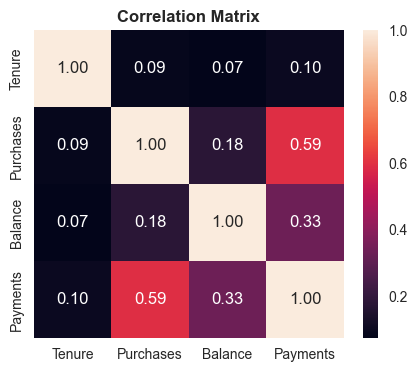

In [18]:
"""
Create a heatmap to visualize correlation matrix
- annot=True: displays correlation values in each cell
Heatmaps make it easy to spot strong relationships between variables
"""

plt.figure(figsize=(5,4))
sns.heatmap(df_cleaned[['Tenure', 'Purchases', 'Balance', 'Payments']].corr(numeric_only=True), annot=True, fmt ='.2f')
plt.title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.show()

From the heatmap above, we can observe that customer tenure does not have a strong correlation with 'Purchases', 'Balance', or 'Payments', as all correlation values are ≤ 0.1. Among these, 'Payments' has the highest correlation with 'Tenure', suggesting that the longer a customer holds a credit card, the higher their payment amounts tend to be — indicating increased credit card usage over time. However, this correlation will be examined more thoroughly in the Feature Engineering section.

Additionally, 'Balance' shows a moderate correlation with both 'Purchases' and 
'Payments', with correlation values of 0.59 and 0.33 respectively. This suggests that customers with a higher account balance tend to make more purchases and have a greater capacity to make payments.

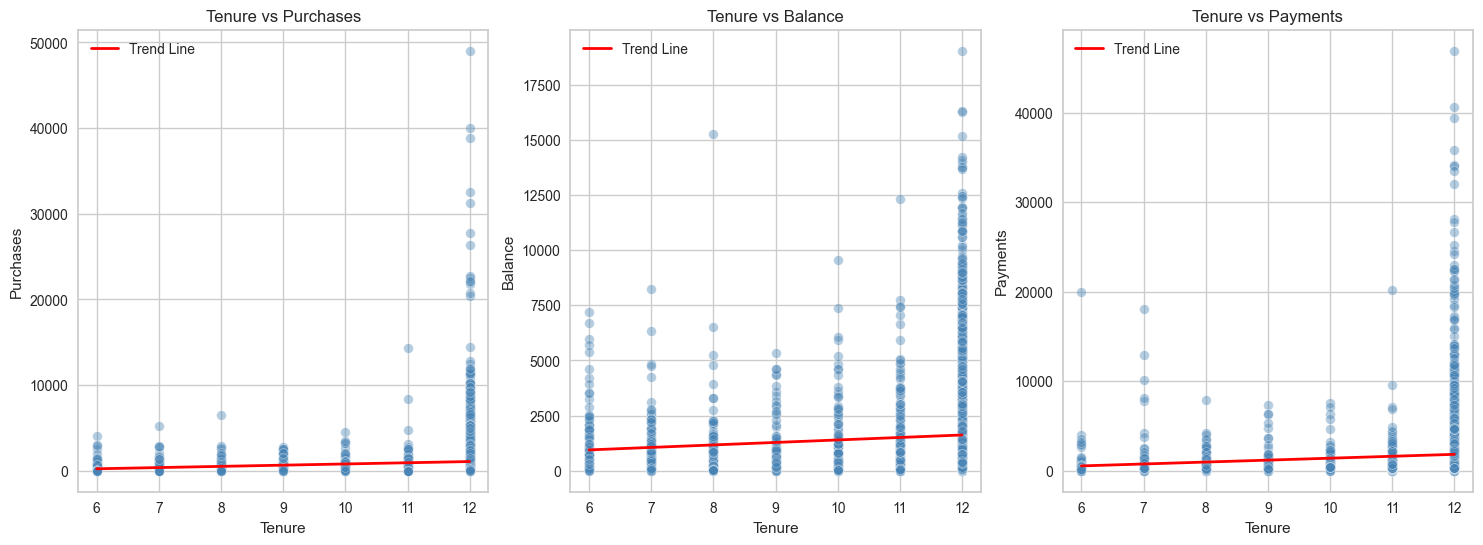

In [19]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))

#plot Scatter Plot
#for 'Tenure' vs 'Purchases'
axes[0].scatter(df_cleaned['Tenure'], df_cleaned['Purchases'], alpha=0.4, color='steelblue', edgecolors='w', linewidth=0.5)
axes[0].set_title('Tenure vs Purchases')
axes[0].set_xlabel('Tenure')
axes[0].set_ylabel('Purchases')

# Add regression line
m, b = np.polyfit(df_cleaned['Tenure'], df_cleaned['Purchases'], 1)
axes[0].plot(sorted(df_cleaned['Tenure']), 
             [m*x + b for x in sorted(df_cleaned['Tenure'])], 
             color='red', linewidth=2, label='Trend Line')
axes[0].legend()

#for 'Tenure' vs 'Balance'
axes[1].scatter(df_cleaned['Tenure'], df_cleaned['Balance'], alpha=0.4, color='steelblue', edgecolors='w', linewidth=0.5)
axes[1].set_title('Tenure vs Balance')
axes[1].set_xlabel('Tenure')
axes[1].set_ylabel('Balance')

# Add regression line
m, b = np.polyfit(df_cleaned['Tenure'], df_cleaned['Balance'], 1)
axes[1].plot(sorted(df_cleaned['Tenure']), 
             [m*x + b for x in sorted(df_cleaned['Tenure'])], 
             color='red', linewidth=2, label='Trend Line')
axes[1].legend()

#for 'Tenure' vs 'Payments'
axes[2].scatter(df_cleaned['Tenure'], df_cleaned['Payments'], alpha=0.4, color='steelblue', edgecolors='w', linewidth=0.5)
axes[2].set_title('Tenure vs Payments')
axes[2].set_xlabel('Tenure')
axes[2].set_ylabel('Payments')

# Add regression line
m, b = np.polyfit(df_cleaned['Tenure'], df_cleaned['Payments'], 1)
axes[2].plot(sorted(df_cleaned['Tenure']), 
             [m*x + b for x in sorted(df_cleaned['Tenure'])], 
             color='red', linewidth=2, label='Trend Line')
axes[2].legend()

From the figure above, all variables show a slight positive trendline against tenure. However, the relationship between tenure and balance is the most noticeable among the three, where account balance tends to gradually increase the longer a customer holds their credit card. Additionally, customers with a tenure of 12 months show the widest spread and highest values across all three variables.

Business Recommendations:

1. Retain longer-tenure customers: Customers who have been with the bank longer tend to spend more and carry higher balances. The marketing team should consider investing in loyalty programs, exclusive perks, and card upgrade offerings tailored specifically for long-tenured customers.

2. Offer premium products to long-tenure customers (12+ months): Customers with longer tenure demonstrate higher purchase and payment behavior. Offering premium products such as card upgrades, investment products, or travel perks could drive greater engagement and benefit the bank in the long term.

3. Nurture customers approaching 12 months of tenure: Customers currently at 10-11 months of tenure should be targeted with incentives such as rewards or credit limit increases to encourage them to remain active and reach the 12-month milestone, converting them into the high-value customer segment.

Qustion 2: Analyze the relationship between 'Credit Limit' and 'Purchases Frequency' and deduce from the result whether high 'Credit Limit' affect the purchase frequency. Create visualization that shows this relationship and provide business recommendations for the marketing team. 

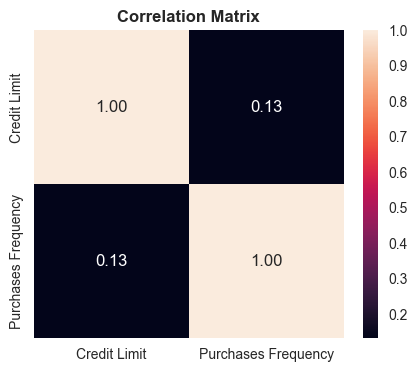

In [20]:
"""
Create a heatmap to visualize correlation matrix
- annot=True: displays correlation values in each cell
Heatmaps make it easy to spot strong relationships between variables
"""

plt.figure(figsize=(5,4))
sns.heatmap(df_cleaned[['Credit Limit', 'Purchases Frequency']].corr(numeric_only=True), annot=True, fmt ='.2f')
plt.title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.show()

From the heatmap above, the correlation between 'Credit Limit' and 'Purchases Frequency' appears to be relatively low despite being positive. To gain a deeper understanding of this relationship, a further visualization will be created to examine whether credit limit has any meaningful impact on purchase frequency.

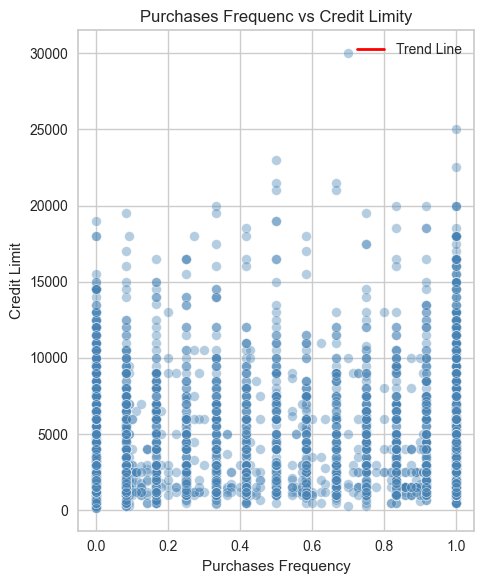

In [21]:
fig, axes = plt.subplots(ncols=1, figsize=(5, 6))

#credit Limit vs Purchases Frequency
axes.scatter(df_cleaned['Purchases Frequency'], df_cleaned['Credit Limit'], alpha=0.4, color='steelblue', edgecolors='w', linewidth=0.5)
axes.set_title('Purchases Frequenc vs Credit Limity')
axes.set_xlabel('Purchases Frequency')
axes.set_ylabel('Credit Limit')

#add regression line
m, b = np.polyfit(df_cleaned['Purchases Frequency'], df_cleaned['Credit Limit'], 1)
axes.plot(sorted(df_cleaned['Purchases Frequency']), 
             [m*x + b for x in sorted(df_cleaned['Purchases Frequency'])], 
             color='red', linewidth=2, label='Trend Line')
axes.legend()

plt.tight_layout()
plt.show()

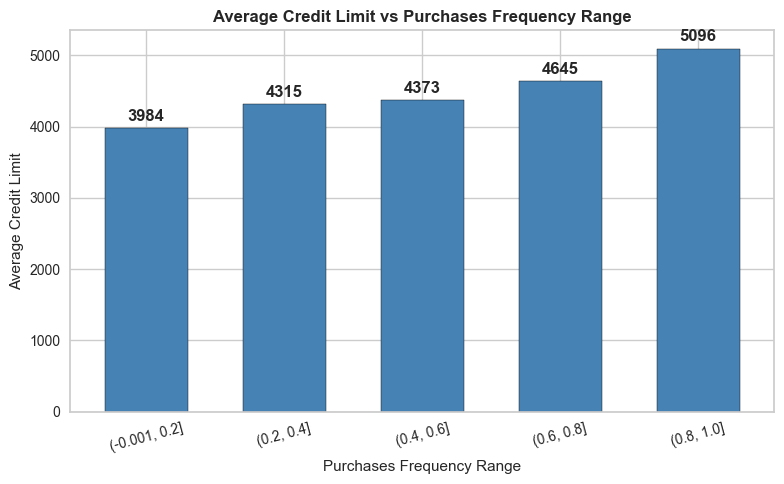

In [22]:
fig, ax = plt.subplots(ncols=1, figsize=(8, 5))

#cmake purchases into 5 bins
df_cleaned['PF Bins'] = pd.cut(df_cleaned['Purchases Frequency'], bins=5)

#average credit limit
credit_limit = df_cleaned.groupby('PF Bins')['Credit Limit'].mean()

# Bar chart
credit_limit.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', width=0.6)
ax.set_xlabel("Purchases Frequency Range")
ax.set_ylabel("Average Credit Limit")
ax.set_title("Average Credit Limit vs Purchases Frequency Range", fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=15)

#label value in each bar
for i, v in enumerate(credit_limit):
    ax.text(i, v + 100, f'{v:.0f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
diff_low_high = ((5096-3984)/3984)*100
print(f"Increase of credit limit: {diff_low_high:.0f}%")

Increase of credit limit: 28%


As seen from the results above, there is a clear positive trend where an increase in credit limit corresponds to an increase in purchase frequency. This suggests that customers with higher credit limits tend to purchase more frequently. Notably, the difference between the lowest and highest credit limit groups is moderate, with approximately a 28% increase in average credit limit from the lowest to the highest purchase frequency group. The highest average credit limit is observed in the purchase frequency range of 0.8–1.0, with an average credit limit of 5096.

Based on these findings, the following business recommendations are proposed for the marketing team:

1. Reward high purchase frequency customers: Offer customers in the 0.8–1.0 purchase frequency range loyalty rewards, cashback programs, and tiered membership benefits based on purchase count. This is aimed at retaining high-frequency customers and encouraging continued spending.

2. Selectively upgrade credit limits for mid-frequency customers: Offering targeted credit limit increases to mid-frequency customers may incentivize them to spend more frequently, gradually moving them into the higher frequency segment.

3. Introduce promotions and offers for low-frequency customers: Targeted introductory promotions and offers should be used to encourage low-frequency customers to increase their spending activity.

4. Implement a tiered milestone program: Customers could be incentivized to reach a certain number of purchases in order to unlock membership tier upgrades, perks, promotions, or discounts — encouraging consistent and repeat purchasing behavior.

VI. Feature Engineering

First, a copy of the cleaned DataFrame will be created to serve as the working 
DataFrame for feature engineering.

In [24]:
#copy the cleaned data to be used in FE 
df_fe = df_uncleaned.copy()

In [25]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4475 entries, 0 to 4474
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Customer ID                       4475 non-null   int64  
 1   Balance                           4475 non-null   float64
 2   Balance Frequency                 4475 non-null   float64
 3   Purchases                         4475 non-null   float64
 4   One-off Purchases                 4475 non-null   float64
 5   Installments Purchases            4475 non-null   float64
 6   Cash Advance                      4475 non-null   float64
 7   Purchases Frequency               4475 non-null   float64
 8   One-off Purchases Frequency       4475 non-null   float64
 9   Purchases Installments Frequency  4475 non-null   float64
 10  Cash Advance Frequency            4475 non-null   float64
 11  Cash Advance Transaction          4475 non-null   int64  
 12  Purcha

From the previous section, only the 'Tenure' column can be classified as an ordinal categorical column, as it represents a fixed number of months. The Customer ID column will be dropped as it only serves as a unique identifier and holds no predictive value for clustering.

a. Splitting numerical column and categorical column

In [26]:
df_fe.columns

Index(['Customer ID', 'Balance', 'Balance Frequency', 'Purchases',
       'One-off Purchases', 'Installments Purchases', 'Cash Advance',
       'Purchases Frequency', 'One-off Purchases Frequency',
       'Purchases Installments Frequency', 'Cash Advance Frequency',
       'Cash Advance Transaction', 'Purchases Transaction', 'Credit Limit',
       'Payments', 'Minimum Payments', 'Full Payment Percentage', 'Tenure'],
      dtype='object')

In [27]:
# Splitting numeric columns and categorical columns
num_col = ['Balance', 'Balance Frequency', 'Purchases',
       'One-off Purchases', 'Installments Purchases', 'Cash Advance',
       'Purchases Frequency', 'One-off Purchases Frequency',
       'Purchases Installments Frequency', 'Cash Advance Frequency',
       'Cash Advance Transaction', 'Purchases Transaction', 'Credit Limit',
       'Payments', 'Minimum Payments', 'Full Payment Percentage']

cat_col = ['Tenure'] #ordinal categorical

All features are numerical, however the 'Tenure' column can be treated as an ordinal categorical feature due to its meaningful numeric order.

b. Missing value handling

For clustering, train-test splitting is not required as clustering is an unsupervised learning technique. Additionally, there is no need to separate features from a target variable, since the goal is to handle dimensionality across all features and perform clustering on the entire dataset. We will now proceed to handling missing values.

In [28]:
df_fe.isnull().sum()

Customer ID                           0
Balance                               0
Balance Frequency                     0
Purchases                             0
One-off Purchases                     0
Installments Purchases                0
Cash Advance                          0
Purchases Frequency                   0
One-off Purchases Frequency           0
Purchases Installments Frequency      0
Cash Advance Frequency                0
Cash Advance Transaction              0
Purchases Transaction                 0
Credit Limit                          1
Payments                              0
Minimum Payments                    158
Full Payment Percentage               0
Tenure                                0
dtype: int64

From the data above, there are 2 columns with null values: 'Credit Limit' (1 null) and 'Minimum Payments' (158 nulls). Missing value handling is required before proceeding to dimensionality reduction.

In handling numerical missing values, we first need to assess the proportion of missing data. In this case, only 2 columns contain missing values.

In [29]:
print(f"%Missing Credit Limit: {((df_fe['Credit Limit'].isnull().sum())/len(df_fe))*100}%")
print(f"%Missing Minimum Payments: {((df_fe['Minimum Payments'].isnull().sum())/len(df_fe))*100}%")
print()

%Missing Credit Limit: 0.0223463687150838%
%Missing Minimum Payments: 3.53072625698324%



The missing values account for less than 5% of the data in each column, making it statistically safe to remove them. However, before deciding to drop the rows, it is important to investigate the nature of the missingness — whether it is MNAR, MAR, or MCAR. Imputing these values using mean or median would not be appropriate, as it would not accurately represent the true financial profile of the customer.

In [30]:
df_fe[df_fe['Credit Limit'].isna()]

,Customer ID,Balance,Balance Frequency,Purchases,One-off Purchases,Installments Purchases,Cash Advance,Purchases Frequency,One-off Purchases Frequency,Purchases Installments Frequency,Cash Advance Frequency,Cash Advance Transaction,Purchases Transaction,Credit Limit,Payments,Minimum Payments,Full Payment Percentage,Tenure
533,4956,18.400472,0.166667,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6


From the results above, the missing data in 'Credit Limit' can be classified as MNAR (Missing Not At Random). The affected customers show no purchase activity and rely solely on cash advances, while only making minimum payments, suggesting financial difficulty. The missing credit limit may indicate that the credit card has been withheld or suspended due to a risky financial profile. Since the missingness is tied to the customer's financial situation rather than occurring randomly, this is classified as MNAR. These rows will therefore be dropped.

In [31]:
# Dropping the null value
df_fe = df_fe.dropna(subset=['Credit Limit'])

# Get index of the cleaned data
valid_index = df_fe.index

# Checking the missing value now
print(f"missing value:\n {df_fe['Credit Limit'].isnull().sum()}")

missing value:
 0


The missing values in 'Credit Limit' have been successfully removed. We will now proceed to handling the missing values in 'Minimum Payments'.

In [32]:
df_fe[df_fe['Minimum Payments'].isna()] 

,Customer ID,Balance,Balance Frequency,Purchases,One-off Purchases,Installments Purchases,Cash Advance,Purchases Frequency,One-off Purchases Frequency,Purchases Installments Frequency,Cash Advance Frequency,Cash Advance Transaction,Purchases Transaction,Credit Limit,Payments,Minimum Payments,Full Payment Percentage,Tenure
120,3764,2557.241228,1.000000,2131.06,749.47,1381.59,0.000000,0.916667,0.500000,0.833333,0.000000,0,55,5000.0,0.000000,NaN,0.0,12
121,4066,176.721561,1.000000,1707.26,403.54,1303.72,0.000000,0.916667,0.083333,0.833333,0.000000,0,18,3300.0,0.000000,NaN,0.0,12
140,7888,79.625341,1.000000,701.44,701.44,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,13,6000.0,0.000000,NaN,0.0,12
164,2004,172.316897,0.181818,368.49,368.49,0.00,1731.561995,0.083333,0.083333,0.000000,0.166667,16,2,2500.0,0.000000,NaN,0.0,12
354,4564,61.463647,0.166667,0.00,0.00,0.00,989.053104,0.000000,0.000000,0.000000,0.166667,2,0,1200.0,0.000000,NaN,0.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4403,5746,18.906225,0.272727,143.73,0.00,143.73,0.000000,0.250000,0.000000,0.166667,0.000000,0,3,2500.0,0.000000,NaN,0.0,12
4404,6720,1311.995984,1.000000,1283.90,1283.90,0.00,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12
4407,4940,0.000000,0.000000,113.00,0.00,113.00,0.000000,0.333333,0.000000,0.333333,0.000000,0,5,4000.0,268.521412,NaN,0.0,12
4416,5144,0.000000,0.000000,581.00,0.00,581.00,0.000000,0.583333,0.000000,0.583333,0.000000,0,7,1000.0,692.523718,NaN,0.0,12


From the results above, the missing data in 'Minimum Payments' can be classified as MAR (Missing At Random), as the missingness can be explained by other observed columns such as 'Full Payment Percentage' and 'Payments'. Customers with a missing 'Minimum Payments' value tend to also have a value of 0 in both 'Full Payment Percentage' and 'Payments', suggesting that the banking system may not log minimum payment data when no payment activity is recorded. These rows will therefore be dropped.

In [33]:
# Dropping the null value
df_fe = df_fe.dropna(subset=['Minimum Payments'])

# Checking the missing value now
print(f"missing value:\n {df_fe['Minimum Payments'].isnull().sum()}")

missing value:
 0


The missing values in 'Minimum Payments' have been successfully removed. We will now proceed to the next step.

As confirmed above, there are no remaining missing values in the dataset. We can now proceed to the next section.

c. Handle Outlier

In [34]:
#function to check skewness in numerical column
def check_skew (df,*column_names):
    return {col: df[col].skew() for col in column_names if col in df.columns}

Next, the skewness of each feature in the DataFrame is calculated as shown below.

In [35]:
num_col

['Balance',
 'Balance Frequency',
 'Purchases',
 'One-off Purchases',
 'Installments Purchases',
 'Cash Advance',
 'Purchases Frequency',
 'One-off Purchases Frequency',
 'Purchases Installments Frequency',
 'Cash Advance Frequency',
 'Cash Advance Transaction',
 'Purchases Transaction',
 'Credit Limit',
 'Payments',
 'Minimum Payments',
 'Full Payment Percentage']

In [36]:
#Calculate skewness in each of the numerical column 
skewness_value = check_skew(df_fe, 'Balance',
 'Balance Frequency',
 'Purchases',
 'One-off Purchases',
 'Installments Purchases',
 'Cash Advance',
 'Purchases Frequency',
 'One-off Purchases Frequency',
 'Purchases Installments Frequency',
 'Cash Advance Frequency',
 'Cash Advance Transaction',
 'Purchases Transaction',
 'Credit Limit',
 'Payments',
 'Minimum Payments',
 'Full Payment Percentage',
 'Tenure')

# Print skewness
for col, skewness in skewness_value.items():
    print(f"{col}: {skewness}")

Balance: 2.440901091038025
Balance Frequency: -2.083168233926597
Purchases: 8.902272454100581
One-off Purchases: 10.045515316290516
Installments Purchases: 8.030304885938177
Cash Advance: 4.713174552567423
Purchases Frequency: 0.035641946018049105
One-off Purchases Frequency: 1.4945047249137602
Purchases Installments Frequency: 0.48657669005693854
Cash Advance Frequency: 1.7888346981313268
Cash Advance Transaction: 4.722877319817404
Purchases Transaction: 4.429897311633813
Credit Limit: 1.5253787831568582
Payments: 5.987444897467956
Minimum Payments: 12.356757627194938
Full Payment Percentage: 1.8543999106579778
Tenure: -2.9969780616789303


In [37]:
#Creating list to categorized which column are normal, skew or extreme skew among the features in X_train
normal_col=[]
skew_col=[]
extreme_skew_col=[]

#looping to categorized the column based on their skewness
for col, skewness in skewness_value.items():
    if skewness < -1 or skewness > 1:
        extreme_skew_col.append(col)
    elif abs(skewness) <=0.5:
        normal_col.append(col)
    else:
        skew_col.append(col)
        
#print the columns in each category
print(f"Normal: {normal_col}\nSkewed: {skew_col}\nExtreme Skewed: {extreme_skew_col}")
        

Normal: ['Purchases Frequency', 'Purchases Installments Frequency']
Skewed: []
Extreme Skewed: ['Balance', 'Balance Frequency', 'Purchases', 'One-off Purchases', 'Installments Purchases', 'Cash Advance', 'One-off Purchases Frequency', 'Cash Advance Frequency', 'Cash Advance Transaction', 'Purchases Transaction', 'Credit Limit', 'Payments', 'Minimum Payments', 'Full Payment Percentage', 'Tenure']


It can be observed that the majority of columns are highly skewed, with the exception of 'Purchases Frequency' and 'Purchases Installments Frequency', which follow a normal distribution. Outlier handling will be applied based on the type of skewness for each column.

For columns with a normal distribution, the Z-score method will be used to detect the proportion of outliers.

In [38]:
def outliers_z_score(df, cols):
    """
    To calculate the Z-score, number and percentage of outliers
    """
    df_fe_zscore_trim = df.copy()
    
    for col in cols:  # Loop through each column
        avg = df[col].mean()
        std = df[col].std()
        
        up_bound = avg + 3 * std
        low_bound = avg - 3 * std
        
        outlier = df[col][(df[col] < low_bound) | (df[col] > up_bound)]
        
        # Filter the dataframe
        df_fe_zscore_trim = df_fe_zscore_trim[(df_fe_zscore_trim[col] >= low_bound) & (df_fe_zscore_trim[col] <= up_bound)]
        
        # Calculate percentage of outliers
        outlier_pct = len(outlier) * 100 / len(df)
        
        # Print results
        results = print(f"Z-SCORE --> {col} --> Upper Bound: {up_bound:.2f}, Lower Bound: {low_bound:.2f}, Outlier: {len(outlier)}, %Outlier: {outlier_pct:.2f}%") 

    return results

In [39]:
outliers_z_score(df_fe, normal_col)

Z-SCORE --> Purchases Frequency --> Upper Bound: 1.69, Lower Bound: -0.70, Outlier: 0, %Outlier: 0.00%
Z-SCORE --> Purchases Installments Frequency --> Upper Bound: 1.56, Lower Bound: -0.82, Outlier: 0, %Outlier: 0.00%


From the outlier percentages above, no outliers were detected in 'Purchases Frequency' or 'Purchases Installments Frequency', therefore no outlier handling is required for these columns.

For skewed and extremely skewed columns, the IQR method will be used to detect the proportion of outliers, as shown below.

In [40]:
def outliers_extreme_IQR(df, cols):
    """
    To calculate the outliers with IQR method, number and percentage of outliers
    """
    # results = {}
    df_filtered = df.copy()
    
    for col in cols:  # Loop through each column
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3-q1
        
        up_bound = q3 + 3 * iqr
        low_bound = q1 - 3 * iqr
        
        outlier = df[col][(df[col] < low_bound) | (df[col] > up_bound)]
        no_outlier = df[col][(df[col] >= low_bound) & (df[col] <= up_bound)]
        
        # Filter the dataframe
        df_filtered = df_filtered[(df_filtered[col] >= low_bound) & (df_filtered[col] <= up_bound)]
        
        # Calculate percentage of outliers
        outlier_pct = len(outlier) * 100 / len(df)
        
        # Store results
        results = print(f"IQR --> {col} --> Upper Bound: {up_bound:.2f}, Lower Bound: {low_bound:.2f}, Outlier:{len(outlier)}, %Outlier: {outlier_pct:.2f}%") 

    
    return results

In [41]:
outliers_extreme_IQR(df_fe, extreme_skew_col)

IQR --> Balance --> Upper Bound: 7991.16, Lower Bound: -5725.83, Outlier:95, %Outlier: 2.20%
IQR --> Balance Frequency --> Upper Bound: 1.27, Lower Bound: 0.64, Outlier:497, %Outlier: 11.52%
IQR --> Purchases --> Upper Bound: 4465.77, Lower Bound: -3271.17, Outlier:173, %Outlier: 4.01%
IQR --> One-off Purchases --> Upper Bound: 2400.00, Lower Bound: -1800.00, Outlier:257, %Outlier: 5.95%
IQR --> Installments Purchases --> Upper Bound: 1994.37, Lower Bound: -1495.78, Outlier:175, %Outlier: 4.05%
IQR --> Cash Advance --> Upper Bound: 4440.99, Lower Bound: -3330.75, Outlier:238, %Outlier: 5.51%
IQR --> One-off Purchases Frequency --> Upper Bound: 1.33, Lower Bound: -1.00, Outlier:0, %Outlier: 0.00%
IQR --> Cash Advance Frequency --> Upper Bound: 1.00, Lower Bound: -0.75, Outlier:2, %Outlier: 0.05%
IQR --> Cash Advance Transaction --> Upper Bound: 16.00, Lower Bound: -12.00, Outlier:178, %Outlier: 4.12%
IQR --> Purchases Transaction --> Upper Bound: 65.00, Lower Bound: -47.00, Outlier:167,

From the outlier percentages above, many columns contain outliers ranging from 
approximately 0% to 12%. Given this range, trimming is not recommended as it would result in significant data loss. Winsorization (capping) is therefore the preferred approach for handling these outliers.

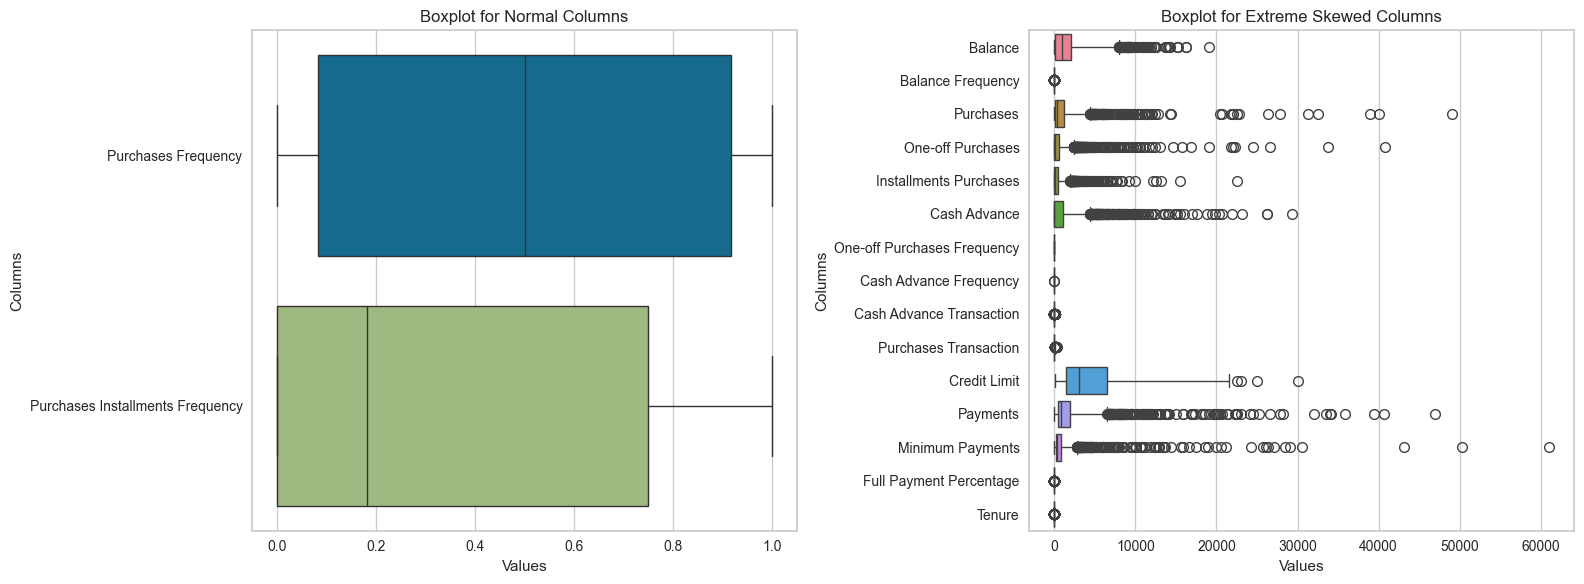

In [42]:
# Create a figure for normal, skewed, and extremely skewed columns
fig, axes = plt.subplots(ncols=2, figsize=(16, 6))

# Boxplot for normal columns
sns.boxplot(data=df_fe[normal_col], orient="h", ax=axes[0])
axes[0].set_title("Boxplot for Normal Columns")
axes[0].set_xlabel("Values")
axes[0].set_ylabel("Columns")


# Boxplot for extreme skewed columns
sns.boxplot(data=df_fe[extreme_skew_col], orient="h", whis=3, ax=axes[1])
axes[1].set_title("Boxplot for Extreme Skewed Columns")
axes[1].set_xlabel("Values")
axes[1].set_ylabel("Columns")

# Display the plot
plt.tight_layout()
plt.show()

As seen from the figure above, a significant number of outliers are detected in the highly skewed columns, while none are present in the normally distributed columns. Winsorization will be applied to cap these outliers within an acceptable distribution range.

We will now apply winsorization to cap the outliers in the dataset.

In [43]:
def apply_winsorization_normal(df, columns, fold=3):
    """
    Winsorization using mean ± fold * std (Gaussian method).
    Suitable for normally distributed columns.
    """
    df = df.copy()
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        lower = mean - fold * std
        upper = mean + fold * std
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df


def apply_winsorization_skew(df, columns, fold=1.5):
    """
    Winsorization using IQR method: median ± fold * IQR.
    Suitable for skewed or extreme skew columns.
    """
    df = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - fold * IQR
        upper = Q3 + fold * IQR
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df

In [44]:
# Check skewness to determine which method to use for each column
skewness = df_fe.skew()
print(skewness)


print(f"Normal columns: {normal_col}")
print(f"Skewed columns: {skew_col}")
print(f"Extreme skew columns: {extreme_skew_col}")

# Apply winsorization based on distribution type
df_fe_winsorized = df_fe.copy()

# Gaussian method for normal columns (3 std)
df_fe_winsorized = apply_winsorization_normal(df_fe_winsorized, normal_col, fold=3)

# IQR method for skewed columns (1.5 IQR)
df_fe_winsorized = apply_winsorization_skew(df_fe_winsorized, skew_col, fold=1.5)

# IQR method for extreme skew columns (3 IQR)
df_fe_winsorized = apply_winsorization_skew(df_fe_winsorized, extreme_skew_col, fold=3)

print(f"\nShape before: {df_fe.shape}")
print(f"Shape after: {df_fe_winsorized.shape}")
df_fe_winsorized.head()

Customer ID                         -0.000256
Balance                              2.440901
Balance Frequency                   -2.083168
Purchases                            8.902272
One-off Purchases                   10.045515
Installments Purchases               8.030305
Cash Advance                         4.713175
Purchases Frequency                  0.035642
One-off Purchases Frequency          1.494505
Purchases Installments Frequency     0.486577
Cash Advance Frequency               1.788835
Cash Advance Transaction             4.722877
Purchases Transaction                4.429897
Credit Limit                         1.525379
Payments                             5.987445
Minimum Payments                    12.356758
Full Payment Percentage              1.854400
Tenure                              -2.996978
dtype: float64
Normal columns: ['Purchases Frequency', 'Purchases Installments Frequency']
Skewed columns: []
Extreme skew columns: ['Balance', 'Balance Frequency', 'Purcha

,Customer ID,Balance,Balance Frequency,Purchases,One-off Purchases,Installments Purchases,Cash Advance,Purchases Frequency,One-off Purchases Frequency,Purchases Installments Frequency,Cash Advance Frequency,Cash Advance Transaction,Purchases Transaction,Credit Limit,Payments,Minimum Payments,Full Payment Percentage,Tenure
0,4004,926.341558,0.909091,45.65,45.65,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,1000.0,1293.650192,2812.991433,0.0,12
1,774,80.336636,0.636364,330.00,330.00,0.00,0.0,0.100000,0.100000,0.000000,0.0,0,1,1800.0,345.330572,85.297166,0.0,12
2,2878,14.074548,1.000000,39.00,0.00,39.00,0.0,0.166667,0.000000,0.166667,0.0,0,2,1500.0,98.947093,74.147879,0.0,12
3,7494,241.223955,0.909091,180.91,180.91,0.00,0.0,0.166667,0.166667,0.000000,0.0,0,6,1400.0,802.858576,220.455533,0.0,12
4,1908,13.362018,0.636364,119.46,60.27,59.19,0.0,0.250000,0.166667,0.083333,0.0,0,4,7500.0,534.740352,132.441551,0.0,12


The bounds used for winsorization are derived from the calculated lower and upper limits for each column.

In [45]:
# Compare before and after
print("="*100)
print("BEFORE vs AFTER WINSORIZATION COMPARISON")
print("="*100)

all_cols = normal_col + skew_col + extreme_skew_col

for col in all_cols:
    print(f"\n{col}:")
    print("-" * 100)
    
    # data comparison
    print("Data comparison:")
    print(f"  Before - Min: {df_fe[col].min():.2f}, Max: {df_fe[col].max():.2f}, Mean: {df_fe[col].mean():.2f}")
    print(f"  After  - Min: {df_fe_winsorized[col].min():.2f}, Max: {df_fe_winsorized[col].max():.2f}, Mean: {df_fe_winsorized[col].mean():.2f}")
    print(f"  Capped values: {(df_fe[col] != df_fe_winsorized[col]).sum()} out of {len(df_fe_winsorized)} ({(df_fe[col] != df_fe_winsorized[col]).sum()/len(df_fe)*100:.1f}%)")
    

BEFORE vs AFTER WINSORIZATION COMPARISON

Purchases Frequency:
----------------------------------------------------------------------------------------------------
Data comparison:
  Before - Min: 0.00, Max: 1.00, Mean: 0.50
  After  - Min: 0.00, Max: 1.00, Mean: 0.50
  Capped values: 0 out of 4316 (0.0%)

Purchases Installments Frequency:
----------------------------------------------------------------------------------------------------
Data comparison:
  Before - Min: 0.00, Max: 1.00, Mean: 0.37
  After  - Min: 0.00, Max: 1.00, Mean: 0.37
  Capped values: 0 out of 4316 (0.0%)

Balance:
----------------------------------------------------------------------------------------------------
Data comparison:
  Before - Min: 0.00, Max: 19043.14, Mean: 1600.11
  After  - Min: 0.00, Max: 7991.16, Mean: 1551.84
  Capped values: 95 out of 4316 (2.2%)

Balance Frequency:
----------------------------------------------------------------------------------------------------
Data comparison:
  Before

From the results, it can be observed that the maximum and minimum values have been adjusted after winsorization, bringing the outliers within a more defined distribution range. To verify the effectiveness of the capping, the data will be visualized to confirm that no outliers remain.

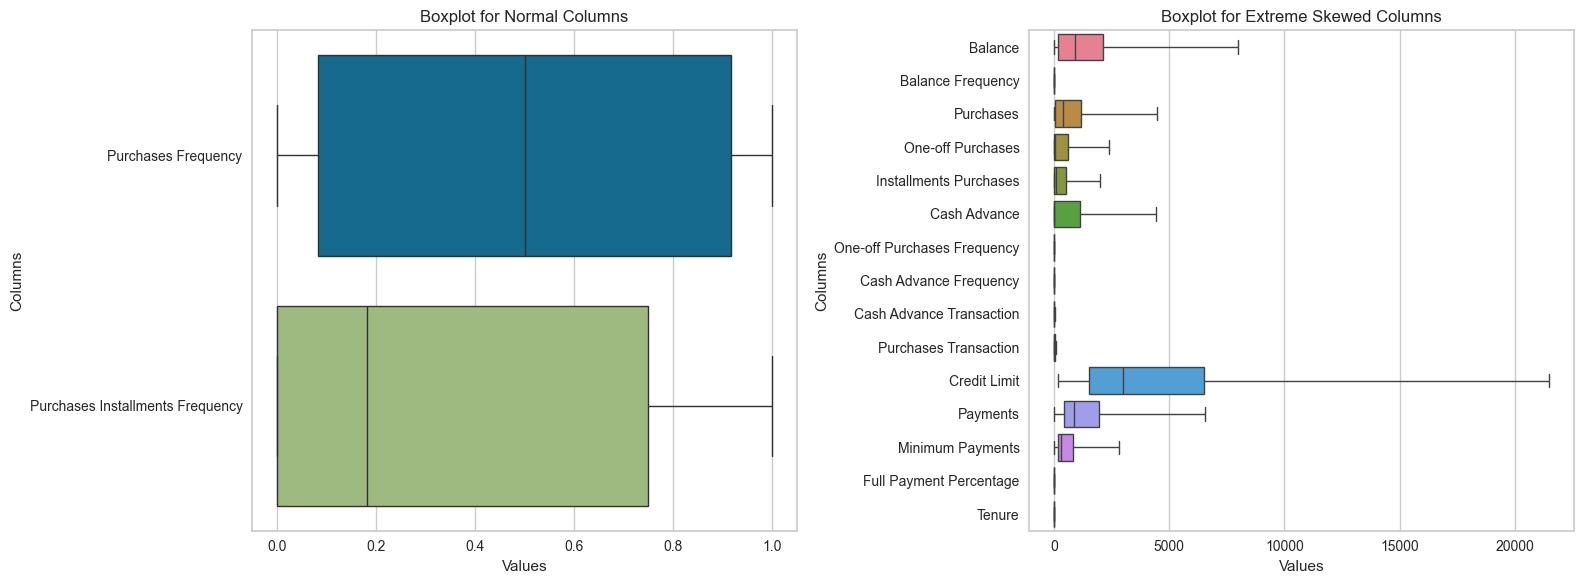

In [46]:
# Create a figure for normal, skewed, and extremely skewed columns
fig, axes = plt.subplots(ncols=2, figsize=(16, 6))

# Boxplot for normal columns
sns.boxplot(data=df_fe_winsorized[normal_col], orient="h", ax=axes[0])
axes[0].set_title("Boxplot for Normal Columns")
axes[0].set_xlabel("Values")
axes[0].set_ylabel("Columns")


# Boxplot for extreme skewed columns
sns.boxplot(data=df_fe_winsorized[extreme_skew_col], orient="h", whis=3, ax=axes[1])
axes[1].set_title("Boxplot for Extreme Skewed Columns")
axes[1].set_xlabel("Values")
axes[1].set_ylabel("Columns")

# Display the plot
plt.tight_layout()
plt.show()

From the figure above, the outliers detected prior to winsorization are no longer visible in the boxplots, confirming that the capping was successful. This helps improve the integrity and reliability of the clustering model.

d. Feature Selection

In this step, columns that are not relevant for PCA and clustering, such as 
'Customer ID', will be dropped from the DataFrame.

In [47]:
df_fe_selected = df_fe_winsorized.drop('Customer ID', axis=1)
df_fe_selected

,Balance,Balance Frequency,Purchases,One-off Purchases,Installments Purchases,Cash Advance,Purchases Frequency,One-off Purchases Frequency,Purchases Installments Frequency,Cash Advance Frequency,Cash Advance Transaction,Purchases Transaction,Credit Limit,Payments,Minimum Payments,Full Payment Percentage,Tenure
0,926.341558,0.909091,45.65,45.65,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1000.0,1293.650192,2812.991433,0.000000,12
1,80.336636,0.636364,330.00,330.00,0.00,0.000000,0.100000,0.100000,0.000000,0.000000,0,1,1800.0,345.330572,85.297166,0.000000,12
2,14.074548,1.000000,39.00,0.00,39.00,0.000000,0.166667,0.000000,0.166667,0.000000,0,2,1500.0,98.947093,74.147879,0.000000,12
3,241.223955,0.909091,180.91,180.91,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,6,1400.0,802.858576,220.455533,0.000000,12
4,13.362018,0.636364,119.46,60.27,59.19,0.000000,0.250000,0.166667,0.083333,0.000000,0,4,7500.0,534.740352,132.441551,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4470,5561.390014,1.000000,0.00,0.00,0.00,3041.330064,0.000000,0.000000,0.000000,0.500000,16,0,6000.0,2193.974270,1558.552940,0.000000,12
4471,1219.143484,0.666667,0.00,0.00,0.00,1893.219765,0.000000,0.000000,0.000000,0.500000,3,0,2000.0,204.789406,274.065414,0.000000,12
4472,5861.100691,1.000000,64.71,64.71,0.00,4440.994105,0.083333,0.083333,0.000000,0.583333,16,2,9000.0,6535.835019,2791.366849,0.083333,12
4473,1432.326731,0.636364,0.00,0.00,0.00,3771.115165,0.000000,0.000000,0.000000,0.625000,15,0,5000.0,138.855523,531.199840,0.000000,12


Next, the correlation between features will be examined to determine which features will be retained for clustering.

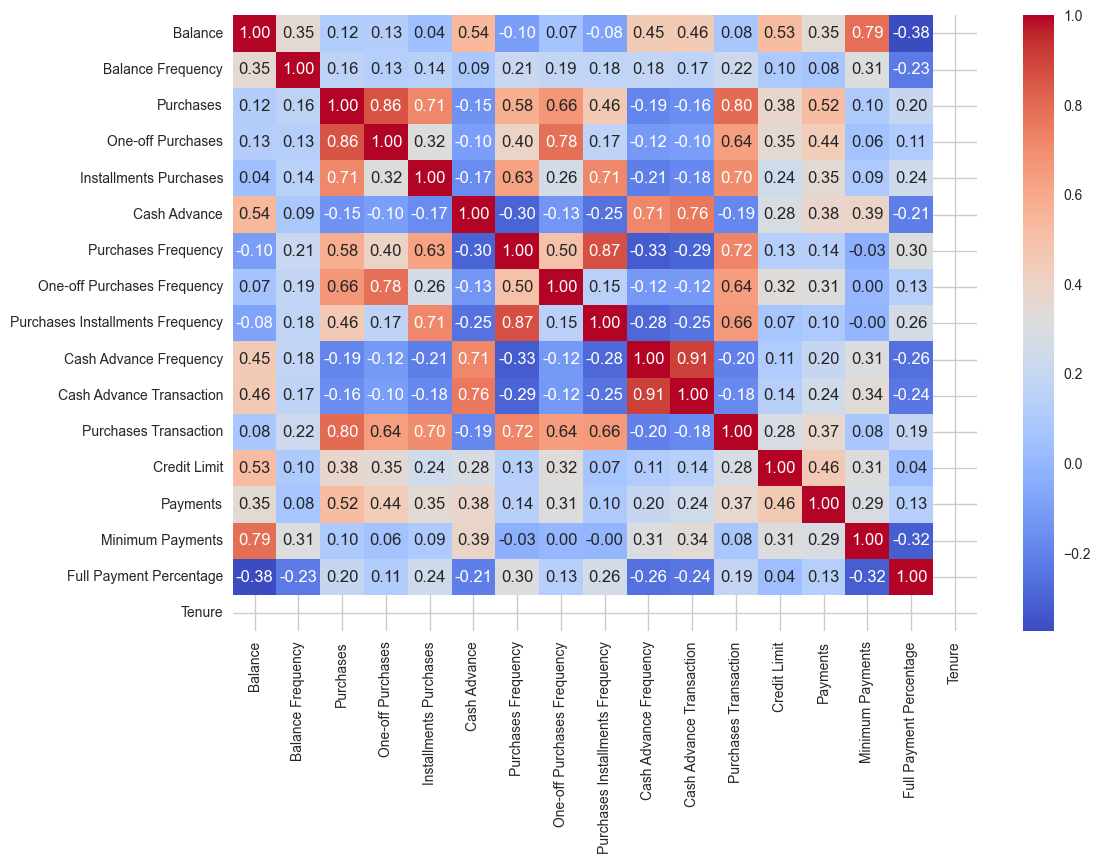

In [48]:
#check correlation
plt.figure(figsize=(12, 8))
sns.heatmap(df_fe_selected.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [49]:
def features_correlation(df, num_cols, cat_cols):
    """
    Correlate all features with each other
    """
    results = {}
    
    # 1. PEARSON CORRELATION (Numerical vs Numerical)
    print("="*70)
    print("PEARSON CORRELATION (Numerical vs Numerical)")
    print("="*70)
    
    pearson_results = []
    for i, col1 in enumerate(num_cols):
        for col2 in num_cols[i+1:]:  # Avoid duplicate pairs
            corr, p_val = pearsonr(df[col1].dropna(), df[col2].dropna())
            pearson_results.append({
                'Feature_1': col1,
                'Feature_2': col2,
                'Pearson_Correlation': corr,
                'Abs_Correlation': abs(corr),
                'p-value': p_val,
                'Significant': 'Yes' if p_val < 0.05 else 'No'
            })
    
    pearson_df = pd.DataFrame(pearson_results).sort_values('Abs_Correlation', ascending=False)
    print(pearson_df.to_string(index=False))
    results['pearson'] = pearson_df

    # 2. SPEARMAN CORRELATION (Numerical vs Numerical - handles non-linear)
    print("\n" + "="*70)
    print("SPEARMAN CORRELATION (Numerical vs Numerical - Monotonic)")
    print("="*70)
    
    spearman_results = []
    for i, col1 in enumerate(num_cols):
        for col2 in num_cols[i+1:]:  # Avoid duplicate pairs
            corr, p_val = spearmanr(df[col1].dropna(), df[col2].dropna())
            spearman_results.append({
                'Feature_1': col1,
                'Feature_2': col2,
                'Spearman_Correlation': corr,
                'Abs_Correlation': abs(corr),
                'p-value': p_val,
                'Significant': 'Yes' if p_val < 0.05 else 'No'
            })
    
    spearman_df = pd.DataFrame(spearman_results).sort_values('Abs_Correlation', ascending=False)
    print(spearman_df.to_string(index=False))
    results['spearman'] = spearman_df

    
    return results


# Call the function
results = features_correlation(
    df_fe_selected,
    num_cols=num_col,
	cat_cols=cat_col
)

PEARSON CORRELATION (Numerical vs Numerical)
                       Feature_1                        Feature_2  Pearson_Correlation  Abs_Correlation       p-value Significant
          Cash Advance Frequency         Cash Advance Transaction             0.905363         0.905363  0.000000e+00         Yes
             Purchases Frequency Purchases Installments Frequency             0.866065         0.866065  0.000000e+00         Yes
                       Purchases                One-off Purchases             0.857595         0.857595  0.000000e+00         Yes
                       Purchases            Purchases Transaction             0.796582         0.796582  0.000000e+00         Yes
                         Balance                 Minimum Payments             0.790045         0.790045  0.000000e+00         Yes
               One-off Purchases      One-off Purchases Frequency             0.782420         0.782420  0.000000e+00         Yes
                    Cash Advance         Cash

The results above display the correlation between features. In practice, feature selection can be skipped entirely since PCA alone is sufficient for handling multicollinearity and dimensionality reduction. However, performing a light feature selection prior to PCA can be beneficial in removing completely redundant columns, making PCA more efficient and its components easier to interpret by reducing noise.

In this case, features with a correlation above 0.95 will be removed, as features exceeding this threshold are considered nearly identical and therefore redundant. The features with correlation > 0.95 are as follows:

- Cash Advance Frequency vs Cash Advance Transaction  →  correlation: 0.9825
- One-off Purchases vs One-off Purchases Frequency    →  correlation: 0.9534
- Cash Advance vs Cash Advance Transaction            →  correlation: 0.9513

As a general rule, when deciding which column to drop, the derived column should be removed while the original column is retained. For example, between 'One-off Purchases' and 'One-off Purchases Frequency', the latter is dropped as it is a derived frequency metric already captured within the original 'One-off Purchases' column. The same logic applies to 'Cash Advance' & 'Cash Advance Transaction' and 'Cash Advance Frequency' & 'Cash Advance Transaction' — 'Cash Advance Transaction' is dropped in both cases as 'Cash Advance' and 'Cash Advance Frequency' are more meaningful and informative for clustering purposes.

Therefore, the following columns will be dropped: One-off Purchases Frequency and Cash Advance Transaction.

In [50]:
drop_cols = ['One-off Purchases Frequency', 'Cash Advance Transaction']
df_fe_selected = df_fe_selected.drop(columns=drop_cols)
print(f"columns after selection: {df_fe_selected.columns.tolist()}")

columns after selection: ['Balance', 'Balance Frequency', 'Purchases', 'One-off Purchases', 'Installments Purchases', 'Cash Advance', 'Purchases Frequency', 'Purchases Installments Frequency', 'Cash Advance Frequency', 'Purchases Transaction', 'Credit Limit', 'Payments', 'Minimum Payments', 'Full Payment Percentage', 'Tenure']


In [51]:
df_fe_selected.head()

,Balance,Balance Frequency,Purchases,One-off Purchases,Installments Purchases,Cash Advance,Purchases Frequency,Purchases Installments Frequency,Cash Advance Frequency,Purchases Transaction,Credit Limit,Payments,Minimum Payments,Full Payment Percentage,Tenure
0,926.341558,0.909091,45.65,45.65,0.00,0.0,0.083333,0.000000,0.0,1,1000.0,1293.650192,2812.991433,0.0,12
1,80.336636,0.636364,330.00,330.00,0.00,0.0,0.100000,0.000000,0.0,1,1800.0,345.330572,85.297166,0.0,12
2,14.074548,1.000000,39.00,0.00,39.00,0.0,0.166667,0.166667,0.0,2,1500.0,98.947093,74.147879,0.0,12
3,241.223955,0.909091,180.91,180.91,0.00,0.0,0.166667,0.000000,0.0,6,1400.0,802.858576,220.455533,0.0,12
4,13.362018,0.636364,119.46,60.27,59.19,0.0,0.250000,0.083333,0.0,4,7500.0,534.740352,132.441551,0.0,12


As seen from above, it can be seen that the column One-off Purchases Frequency', 'Cash Advance Transaction', and 'Customer ID' has already been dropped. 

Lastly, we need to define the numerical columns for the dataframe. For clustering purposes, the 'Tenure' column is already stored as int64 with a meaningful numeric order (6 < 7 < 8 ... < 12), meaning the ordinal relationship is already preserved in its numeric values. Applying an encoder such as OneHotEncoding would actually destroy this ordinal relationship by treating each tenure value as an independent category. Therefore, no encoding is required for 'Tenure' — the only necessary step is to ensure it is properly scaled alongside the other numerical columns using StandardScaler. The final split of numerical and categorical columns is as follows:

In [52]:
num_columns = ['Balance', 'Balance Frequency', 'Purchases', 'One-off Purchases', 'Installments Purchases', 'Cash Advance', 'Purchases Frequency', 'Purchases Installments Frequency', 'Cash Advance Frequency', 'Purchases Transaction', 'Credit Limit', 'Payments', 'Minimum Payments', 'Full Payment Percentage', 'Tenure']
cat_columns = [] #tenure moved to num_columns

df_num = df_fe_selected[num_columns]
df_cat = df_fe_selected[cat_columns]

print('Num Columns : ', num_columns)
print('Cat Columns : ', cat_columns)

Num Columns :  ['Balance', 'Balance Frequency', 'Purchases', 'One-off Purchases', 'Installments Purchases', 'Cash Advance', 'Purchases Frequency', 'Purchases Installments Frequency', 'Cash Advance Frequency', 'Purchases Transaction', 'Credit Limit', 'Payments', 'Minimum Payments', 'Full Payment Percentage', 'Tenure']
Cat Columns :  []


e. Feature Scaling

First, the numerical features will be scaled using StandardScaler. This method is chosen because the data contains high outliers, and StandardScaler is robust in handling such cases while also being well-suited for preprocessing prior to PCA and clustering. MinMaxScaler is not used as it is sensitive to outliers and would distort the clustering results.

In [53]:
scaler = StandardScaler()
df_num_scaled = scaler.fit_transform(df_num)

#check
df_num_scaled

array([[-0.3293765 , -0.11099767, -0.70178912, ...,  2.98955086,
        -0.58649953,  0.        ],
       [-0.77486549, -2.15856781, -0.45655658, ..., -0.76172498,
        -0.58649953,  0.        ],
       [-0.80975775,  0.57152571, -0.70752429, ..., -0.7770581 ,
        -0.58649953,  0.        ],
       ...,
       [ 2.26916731,  0.57152571, -0.68535117, ...,  2.95981154,
        -0.22640469,  0.        ],
       [-0.06293499, -2.15856781, -0.74115914, ..., -0.14849499,
        -0.58649953,  0.        ],
       [ 1.70293034,  0.57152571, -0.74115914, ...,  0.51105199,
        -0.58649953,  0.        ]])

The data has been successfully scaled. We will now proceed to the next step: 
dimensionality reduction using PCA.

f. PCA (Dimensionality Reduction)

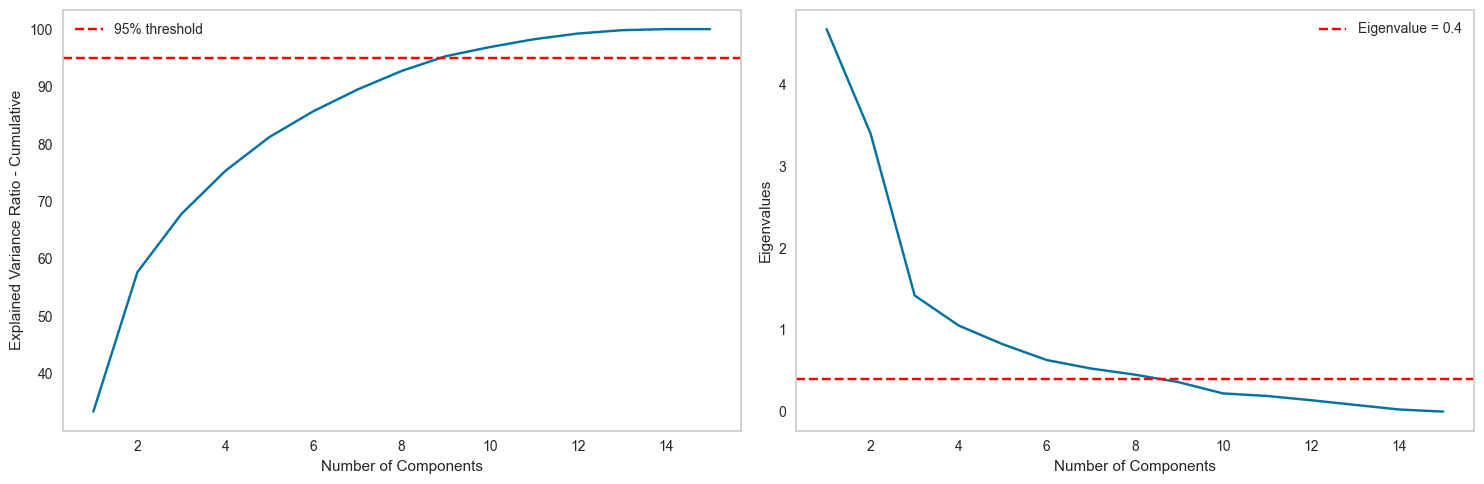

In [54]:
pca = PCA()
pca.fit(df_num_scaled)

n_components = len(pca.explained_variance_ratio_)

# Plot the Cumulative Explained Variance Ratio
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.grid()
plt.plot(range(1, n_components + 1), np.cumsum(pca.explained_variance_ratio_ * 100))
plt.axhline(y=95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio - Cumulative')
plt.legend()

# Plot the Eigenvalues
plt.subplot(1, 2, 2)
plt.grid()
plt.plot(range(1, n_components + 1), pca.explained_variance_)
plt.axhline(y=0.4, color='red', linestyle='--', label='Eigenvalue = 0.4')
plt.xlabel('Number of Components')
plt.ylabel('Eigenvalues')
plt.legend()

plt.tight_layout()
plt.show()

From the figure above, the variance ratio threshold is set at 95%, which recommends approximately 9 components. This is also supported by the eigenvalue plot, where n_components=9 yields an eigenvalue of approximately 0.5. To obtain a more precise recommendation, the exact number of components can be derived using the syntax below.

In [55]:
# Check the number of features if we want to retain 95 % of the information

cumsum = np.cumsum(pca.explained_variance_ratio_)
num_features = np.argmax(cumsum >= 0.95) + 1 #to retain 95% of the data
num_features

9

From the results above, the recommended number of components needed to retain 95% of the variance is 9. This means the features will be reduced from 15 to 9 
components. The model will therefore be trained using 9 components.

In [56]:
# train the data from the 95% original dataset information

pca = PCA(n_components=9) #9 features from recommendation
pca.fit(df_num_scaled)

df_scaled_pca = pca.transform(df_num_scaled)

#check
df_scaled_pca

array([[-1.75645747,  0.51941417,  0.89080165, ..., -2.27490598,
        -0.38880732, -0.14025119],
       [-2.00936951, -1.67811237, -1.13039401, ...,  0.19198129,
        -0.19141767,  0.07984534],
       [-1.75929587, -1.35599796,  0.67915693, ..., -0.02191298,
         0.69614164, -0.01679271],
       ...,
       [-1.15194119,  5.79994671, -0.83211325, ..., -1.36971635,
         0.24642639, -0.92666186],
       [-2.92977223,  1.44041448, -1.36375681, ...,  1.36129982,
        -1.0542666 ,  0.84941768],
       [-2.46569983,  4.21860582, -0.10378307, ...,  1.55424612,
        -0.64500842,  1.23394123]])

As established earlier, the ordinal categorical column 'Tenure' is already stored in numerical format and has been included in the numerical columns. Therefore, no additional encoding is required.

Next, the optimal number of clusters will be determined using the Elbow Method and Silhouette Score, which will be discussed in the following section.

g. Elbow Method

Having determined the number of PCA components, the next step is to determine the optimal number of clusters to divide the data into meaningful groups based on their characteristics. Hard clustering using K-Means will be applied, ensuring that each data point is assigned to one and only one cluster.

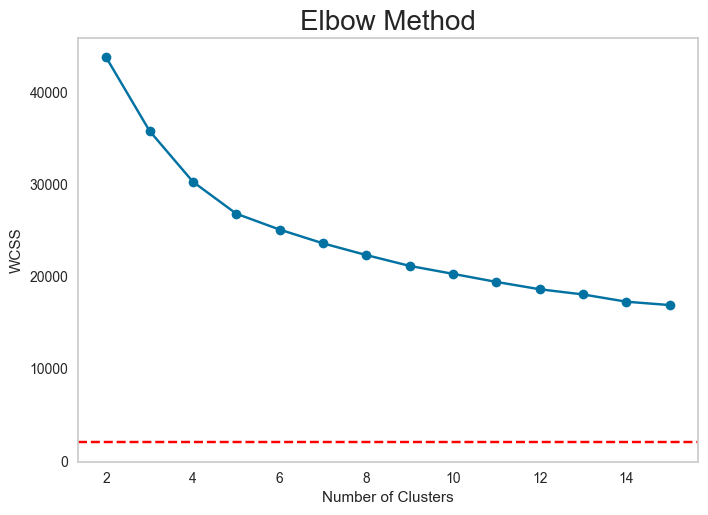

In [57]:
wcss = [] #list to contain the result of wcss score
random_state = 20
max_cluster = 15 #set the looping untul n_cluster = 15
for i in range(2, max_cluster+1): 
    km = KMeans(n_clusters = i,
                init = 'k-means++',
                max_iter = 300,
                n_init = 10,
                random_state = random_state)
    km.fit(df_scaled_pca)
    wcss.append(km.inertia_)

plt.plot(range(2, max_cluster+1), wcss, marker ="o")
plt.grid()
plt.title('Elbow Method', fontsize = 20)
plt.axhline(y=2000, color='red', linestyle='--', label='WCSS 2000 threshold')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

The conventional rule of thumb for the Elbow Method uses a WCSS threshold of 2,000. However, as seen from the figure above, the WCSS values in this case far exceed that threshold, reaching well above 10,000. A higher WCSS indicates greater within-cluster variance and higher residuals, meaning lower clustering quality. Despite this, the elbow point can still be visually identified at around k=5, 6, or 7. The Silhouette Score and Silhouette Plot will be used to validate the optimal number of clusters.

h. Silhouete Score and Plot

The Silhouette Score measures how similar each data point is to its own cluster compared to other clusters. A score close to 1 indicates that data points are well-assigned with no overlap between clusters, which is the ideal outcome. A score near 0 suggests overlapping clusters, which can complicate further analysis. A negative score indicates that data points may have been assigned to the wrong cluster, which is highly undesirable and should be avoided.

In [58]:
# Function to create Silhouette Plot

def plot_silhouette(range_n_clusters, X, random_state):
    for n_clusters in range_n_clusters:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 4)

        # The 1st subplot is the silhouette plot
        # The silhouette coefficient can range from -1, 1 but in this example all lie within [-0.1, 1]
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator seed of 10 for reproducibility.
        clusterer = KMeans(n_clusters = n_clusters, init = 'k-means++', max_iter = 300, n_init = 10, random_state = random_state)
        cluster_labels = clusterer.fit_predict(X)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed clusters
        silhouette_avg = silhouette_score(X, cluster_labels)
        print("For n_clusters =", n_clusters,
              "The average silhouette_score is :", silhouette_avg)

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                              0, ith_cluster_silhouette_values,
                              facecolor=color, edgecolor=color, alpha=0.7)

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                    c=colors, edgecolor='k')

        # Labeling the clusters
        centers = clusterer.cluster_centers_

        # Draw white circles at cluster centers
        ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                    c="white", alpha=1, s=200, edgecolor='k')

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                      "with n_clusters = %d" % n_clusters),
                     fontsize=14, fontweight='bold')

For n_clusters = 2 The average silhouette_score is : 0.2553724289914005
For n_clusters = 3 The average silhouette_score is : 0.25880259305770253
For n_clusters = 4 The average silhouette_score is : 0.23557037108236994
For n_clusters = 5 The average silhouette_score is : 0.244723929544209
For n_clusters = 6 The average silhouette_score is : 0.23517729481161
For n_clusters = 7 The average silhouette_score is : 0.23528158760045786
For n_clusters = 8 The average silhouette_score is : 0.22618894888502913
For n_clusters = 9 The average silhouette_score is : 0.233204879087966
For n_clusters = 10 The average silhouette_score is : 0.22847905484371742
For n_clusters = 11 The average silhouette_score is : 0.23176153844161898
For n_clusters = 12 The average silhouette_score is : 0.21331244765182647
For n_clusters = 13 The average silhouette_score is : 0.21591238909417965
For n_clusters = 14 The average silhouette_score is : 0.21645020940225135


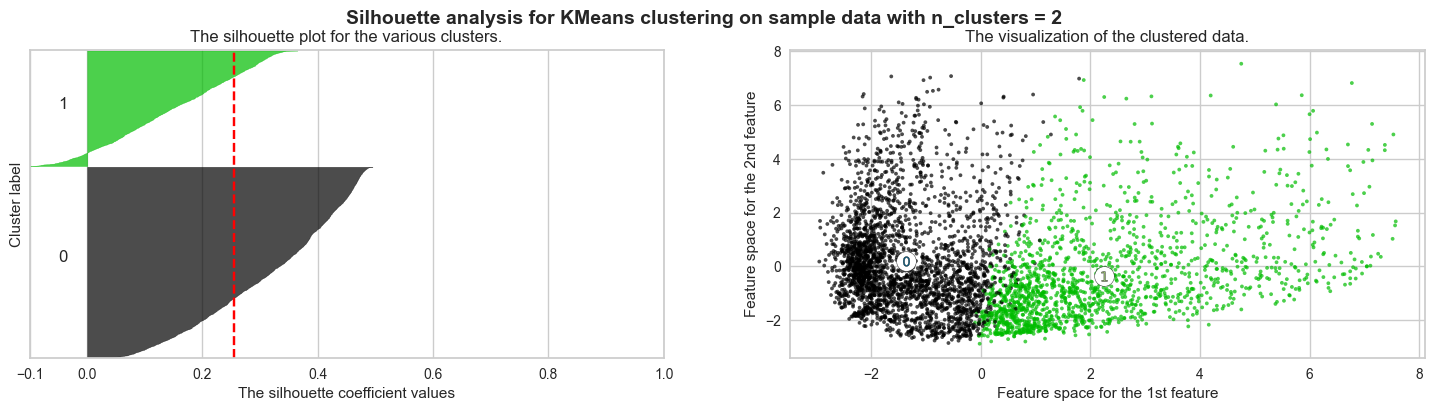

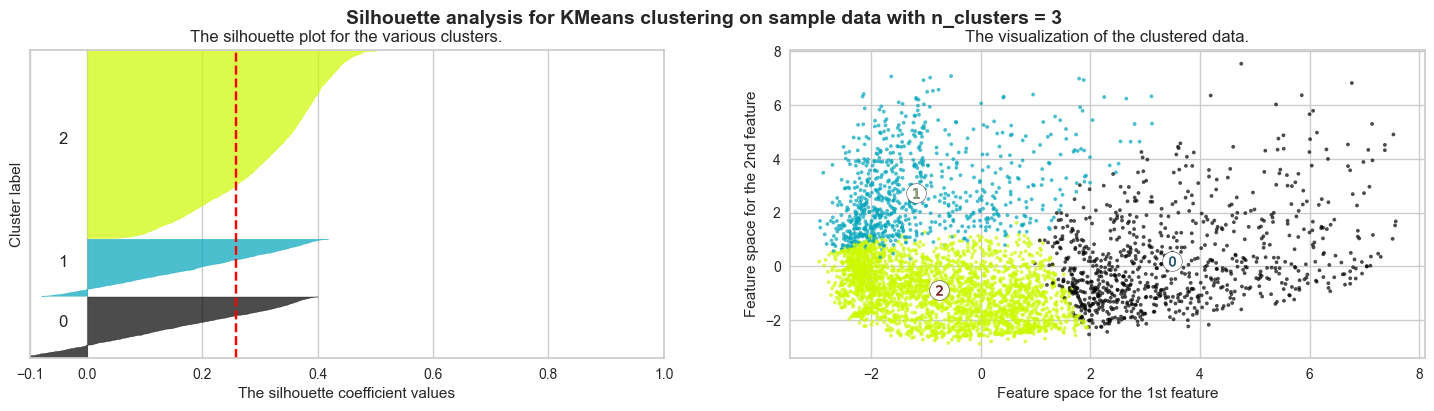

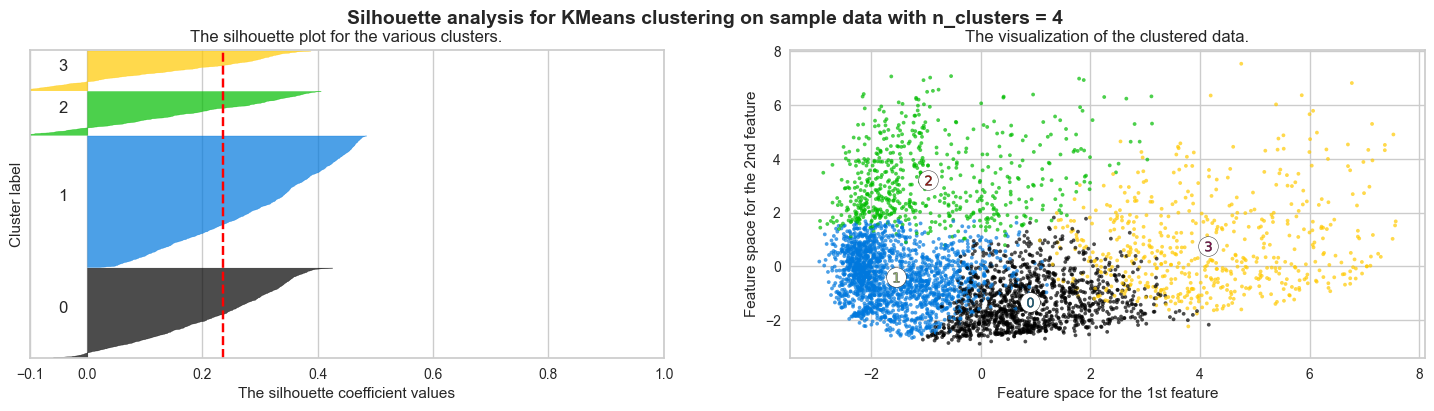

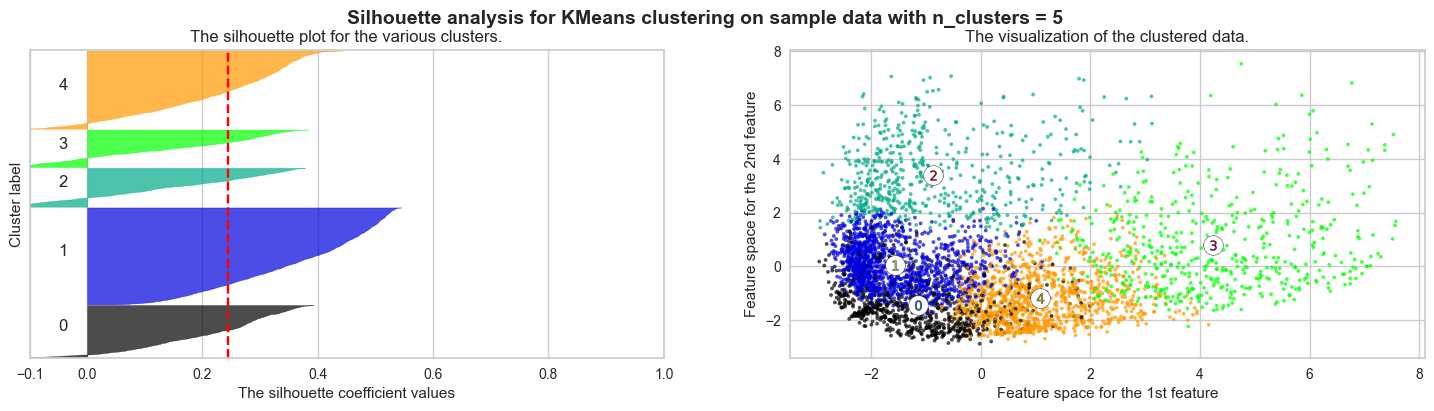

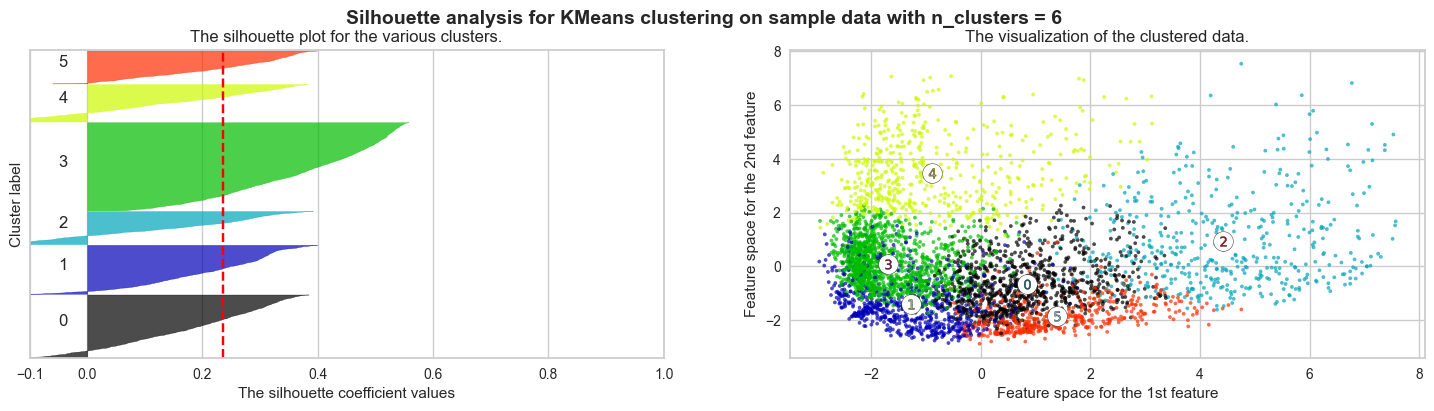

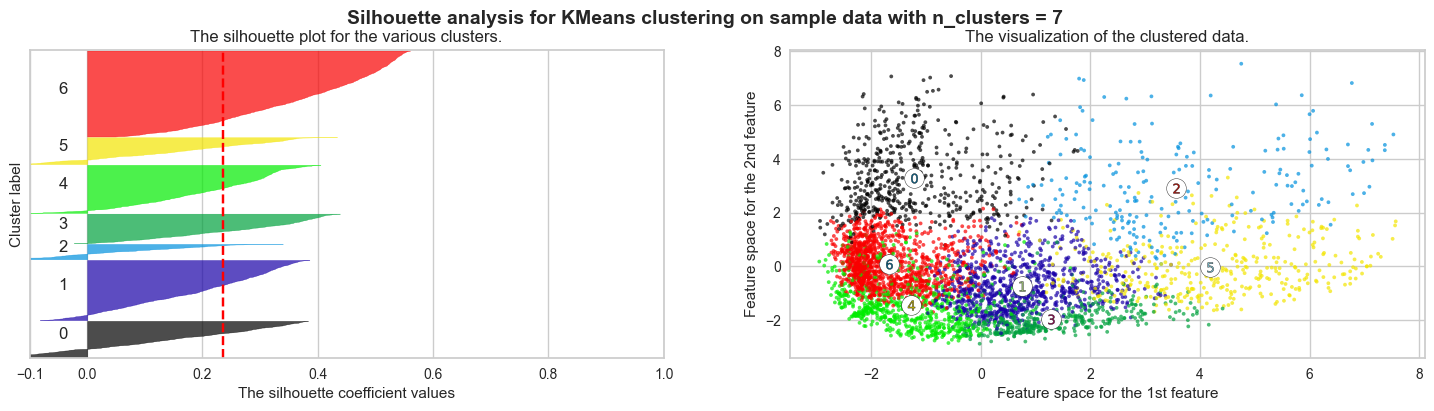

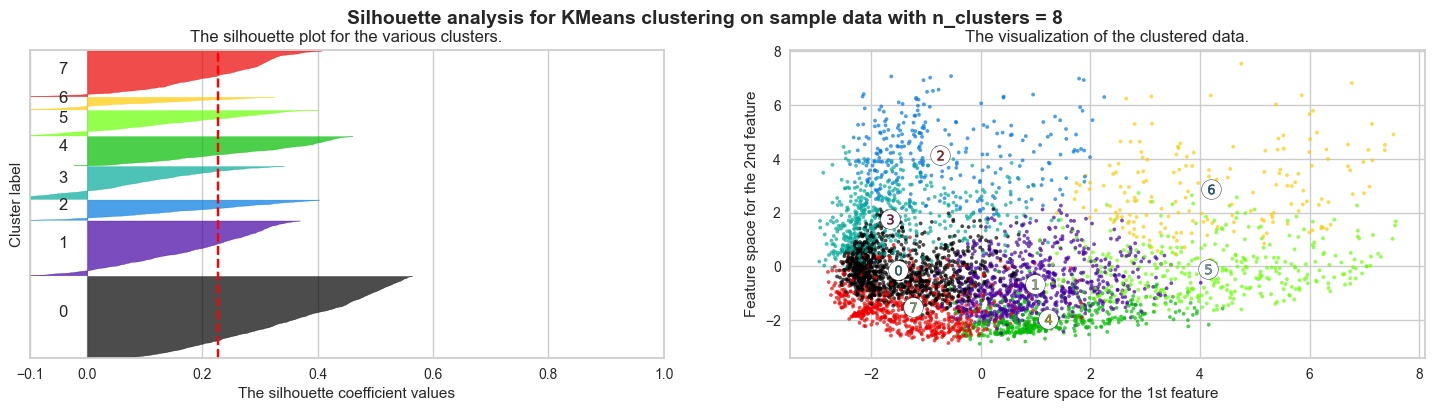

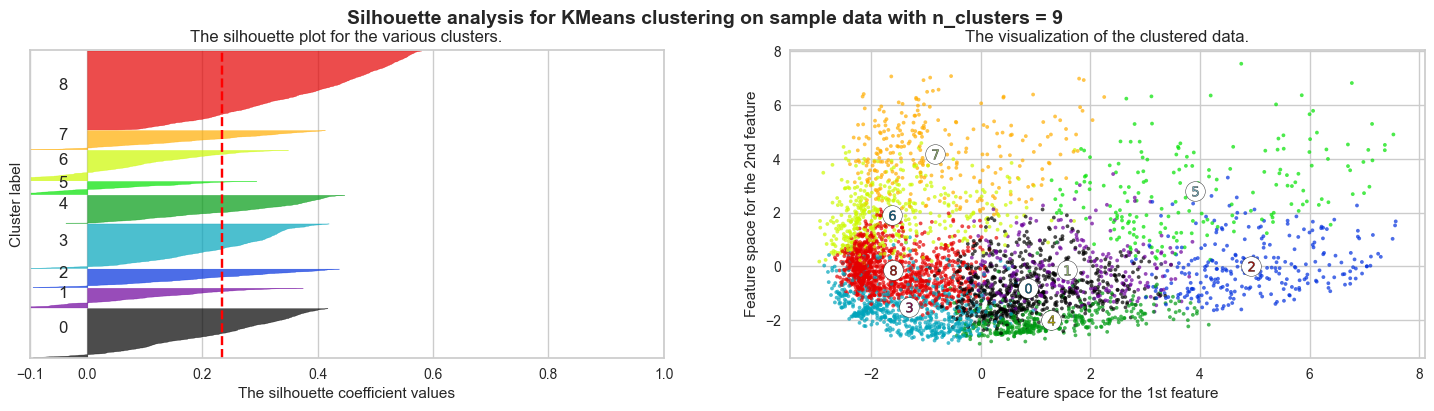

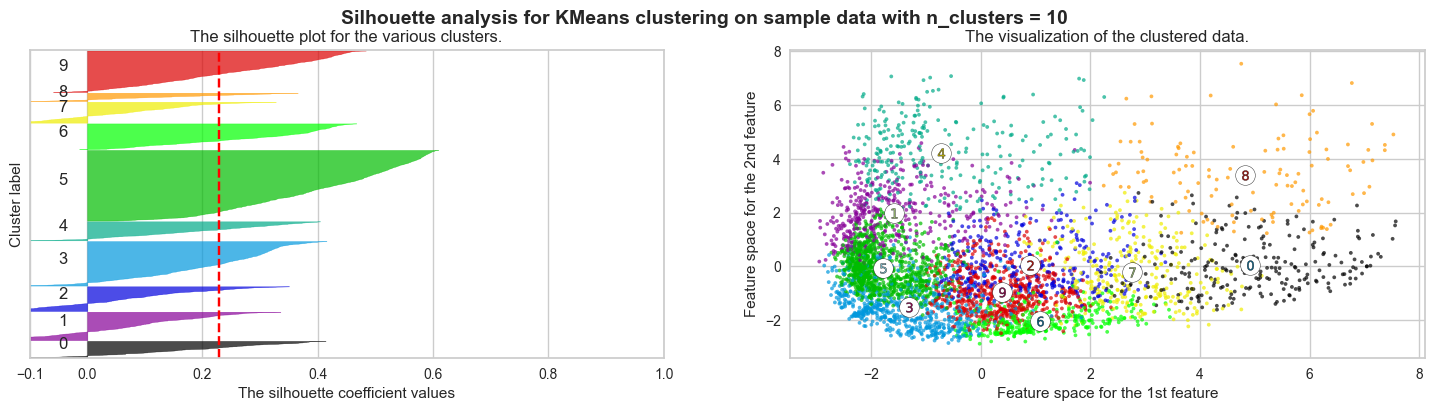

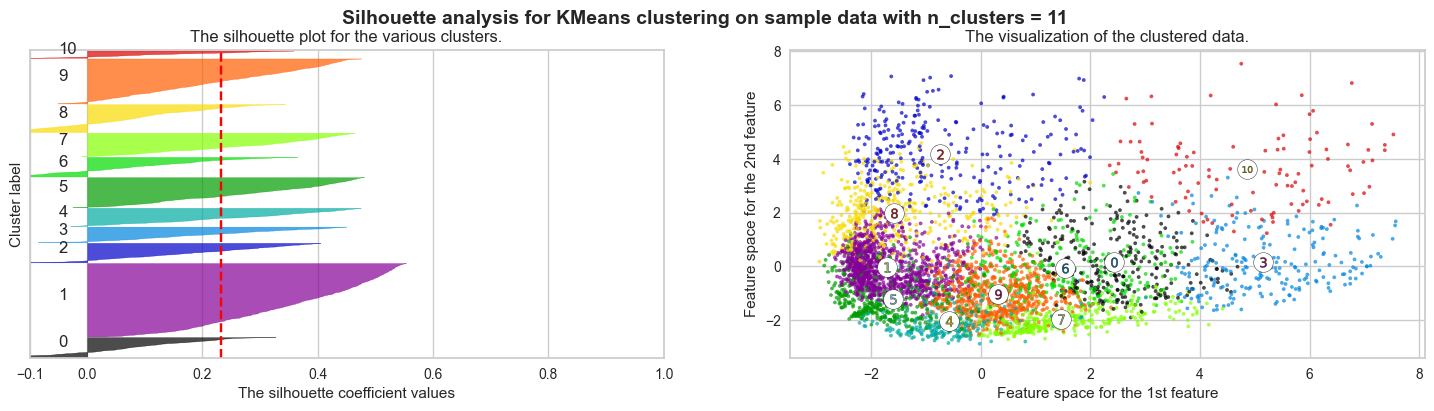

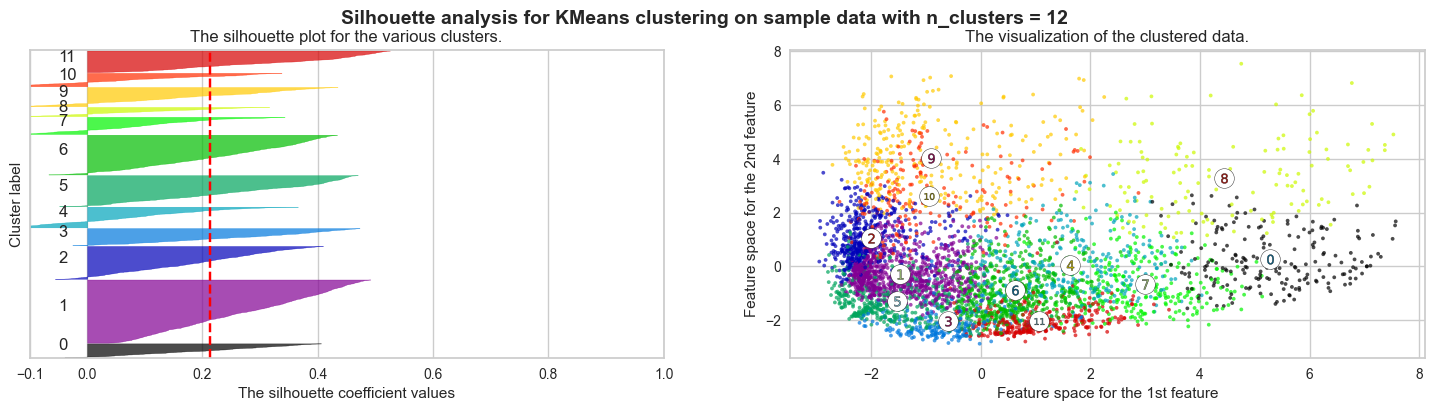

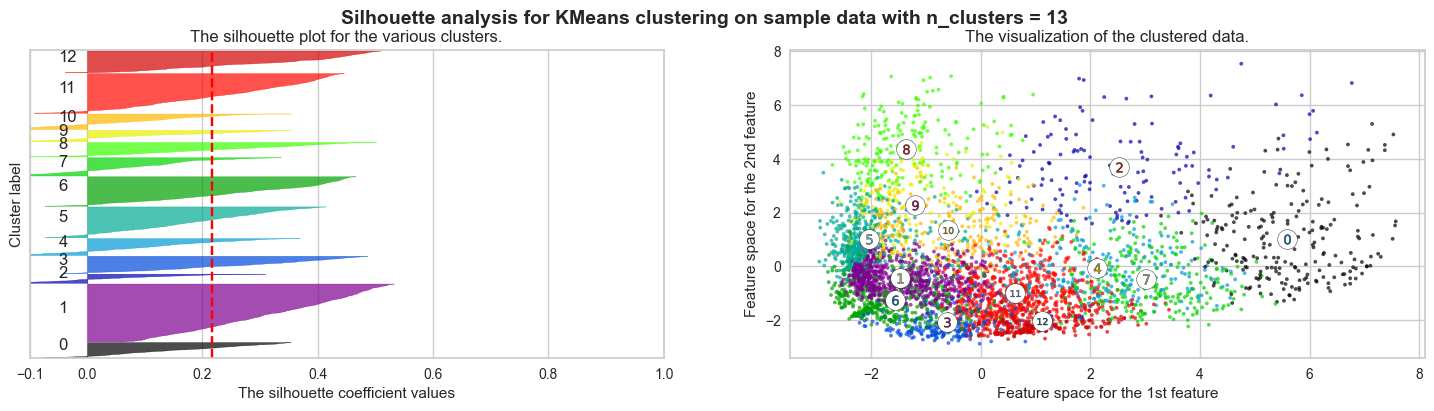

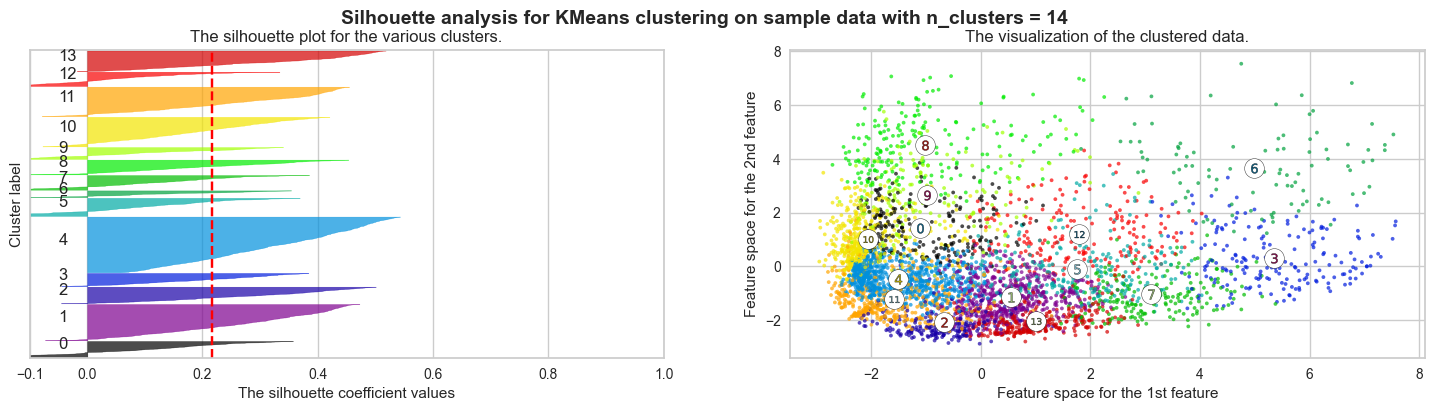

In [59]:
# Display the Silhouette Score and Plot Silhouette Plot

plot_silhouette(range(2, max_cluster), df_scaled_pca, random_state)

From the results above, the Silhouette Scores are generally low, leaning closer to 0 than to 1, indicating a likelihood of overlapping clusters which may reduce prediction accuracy. Based on the earlier Elbow Method, the candidate number of clusters falls between 5, 6, and 7. Although n_clusters=3 yields the highest Silhouette Score, its cluster distribution is highly imbalanced. Among the candidate values, n_clusters=5 achieves the highest Silhouette Score of 0.2447 and will therefore be selected as the optimal cluster size.

VII. Model Definition

The chosen clustering algorithm is K-Means. This algorithm is selected because all features are numerical in nature. Although 'Tenure' may be considered an ordinal categorical column, it is already stored as a numerical value, making K-Means appropriate. K-Prototypes would only be necessary if the dataset contained a true mix of categorical (string) and numerical columns.

In [60]:
# defining the model

km = KMeans(n_clusters = 5, init = 'k-means++', max_iter = 300, n_init = 10, random_state = random_state)


VIII. Model Training

In [61]:
pred = km.fit_predict(df_scaled_pca)
pred

array([1, 0, 1, ..., 2, 2, 2])

The results above show that each data entry has been assigned to a cluster (0, 1, 2, 3, or 4) according to its index. For ease of analysis, the cluster labels will be renamed. However, the cluster predictions will first be inserted into the DataFrame before renaming.

In [62]:
# Insert clustering result into data set before winsorization

df_fe['Cluster'] = pred
df_fe.head()

,Customer ID,Balance,Balance Frequency,Purchases,One-off Purchases,Installments Purchases,Cash Advance,Purchases Frequency,One-off Purchases Frequency,Purchases Installments Frequency,Cash Advance Frequency,Cash Advance Transaction,Purchases Transaction,Credit Limit,Payments,Minimum Payments,Full Payment Percentage,Tenure,Cluster
0,4004,926.341558,0.909091,45.65,45.65,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,1000.0,1293.650192,9957.742740,0.0,12,1
1,774,80.336636,0.600000,330.00,330.00,0.00,0.0,0.100000,0.100000,0.000000,0.0,0,1,1800.0,345.330572,85.297166,0.0,10,0
2,2878,14.074548,1.000000,39.00,0.00,39.00,0.0,0.166667,0.000000,0.166667,0.0,0,2,1500.0,98.947093,74.147879,0.0,12,1
3,7494,241.223955,0.909091,180.91,180.91,0.00,0.0,0.166667,0.166667,0.000000,0.0,0,6,1400.0,802.858576,220.455533,0.0,12,1
4,1908,13.362018,0.363636,119.46,60.27,59.19,0.0,0.250000,0.166667,0.083333,0.0,0,4,7500.0,534.740352,132.441551,0.0,12,0


From the table above, the cluster predictions have been successfully concatenated into the DataFrame. The cluster labels will now be renamed to Cluster A, B, C, D, and E.

In [63]:
df_fe['Cluster'] = df_fe['Cluster'].replace({0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'})
#check
df_fe.head(10)    
    

,Customer ID,Balance,Balance Frequency,Purchases,One-off Purchases,Installments Purchases,Cash Advance,Purchases Frequency,One-off Purchases Frequency,Purchases Installments Frequency,Cash Advance Frequency,Cash Advance Transaction,Purchases Transaction,Credit Limit,Payments,Minimum Payments,Full Payment Percentage,Tenure,Cluster
0,4004,926.341558,0.909091,45.65,45.65,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,1000.0,1293.650192,9957.742740,0.000000,12,B
1,774,80.336636,0.600000,330.00,330.00,0.00,0.0,0.100000,0.100000,0.000000,0.0,0,1,1800.0,345.330572,85.297166,0.000000,10,A
2,2878,14.074548,1.000000,39.00,0.00,39.00,0.0,0.166667,0.000000,0.166667,0.0,0,2,1500.0,98.947093,74.147879,0.000000,12,B
3,7494,241.223955,0.909091,180.91,180.91,0.00,0.0,0.166667,0.166667,0.000000,0.0,0,6,1400.0,802.858576,220.455533,0.000000,12,B
4,1908,13.362018,0.363636,119.46,60.27,59.19,0.0,0.250000,0.166667,0.083333,0.0,0,4,7500.0,534.740352,132.441551,0.000000,12,A
5,5588,242.161751,1.000000,686.00,686.00,0.00,0.0,0.250000,0.250000,0.000000,0.0,0,5,1600.0,79.554524,142.159120,0.000000,12,B
6,6294,768.881695,0.727273,408.59,408.59,0.00,0.0,0.250000,0.250000,0.000000,0.0,0,7,2500.0,2095.952073,250.856639,0.125000,12,A
7,1366,6.793588,0.363636,2634.37,1773.40,860.97,0.0,0.333333,0.333333,0.333333,0.0,0,24,4000.0,4144.707044,49.647266,0.000000,12,A
8,7726,131.271213,1.000000,147.26,0.00,147.26,0.0,0.333333,0.000000,0.250000,0.0,0,4,1000.0,430.455738,163.227325,0.090909,12,B
9,2182,7.388588,0.545455,84.05,0.00,84.05,0.0,0.416667,0.000000,0.416667,0.0,0,5,4000.0,171.883336,99.694319,0.200000,12,A


From the results above, the cluster prediction labels have been successfully renamed and updated in the DataFrame. We will now proceed to cluster visualization to assess the quality of the clustering.

<Axes: >

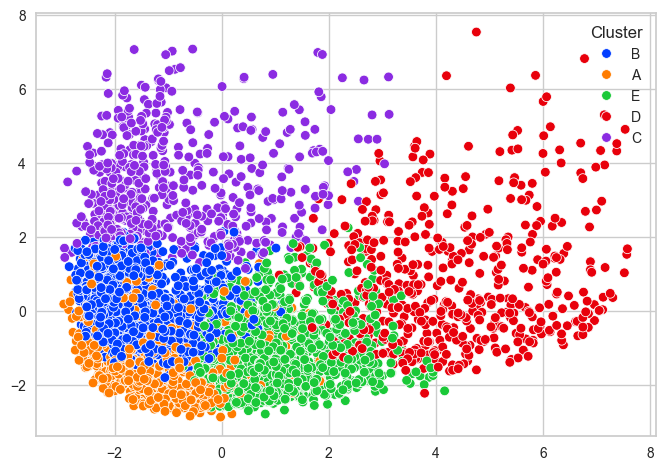

In [64]:
# Cluster visualization in 2D

pca_2d = PCA(n_components=2)
pca_2d.fit(df_num_scaled)

sales_scaled_pca_2d = pca_2d.fit_transform(df_num_scaled)

sns.scatterplot(x=sales_scaled_pca_2d[:,0], y=sales_scaled_pca_2d[:,1], hue=df_fe['Cluster'], palette='bright')

From the visualization above, there is a noticeable degree of overlap between clusters, particularly Cluster A, which overlaps significantly with Clusters E and B. Clusters C and D show a more scattered distribution with data points spread out rather than forming tight, well-defined groups.

A pipeline will now be created for data inference to streamline the prediction process.

In [65]:
num_columns

['Balance',
 'Balance Frequency',
 'Purchases',
 'One-off Purchases',
 'Installments Purchases',
 'Cash Advance',
 'Purchases Frequency',
 'Purchases Installments Frequency',
 'Cash Advance Frequency',
 'Purchases Transaction',
 'Credit Limit',
 'Payments',
 'Minimum Payments',
 'Full Payment Percentage',
 'Tenure']

In [66]:
# Define columns after feature selection
num_columns = ['Balance',
 'Balance Frequency',
 'Purchases',
 'One-off Purchases',
 'Installments Purchases',
 'Cash Advance',
 'Purchases Frequency',
 'Purchases Installments Frequency',
 'Cash Advance Frequency',
 'Purchases Transaction',
 'Credit Limit',
 'Payments',
 'Minimum Payments',
 'Full Payment Percentage',
 'Tenure']

preprocessor = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=11))
])

km = {
    'KMeans': KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=random_state)
}

pipelines = {}
for name, model in km.items():
    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('kmeans', model)
    ])
    pipelines[name].fit(df_fe[num_columns])

print("Pipeline fitted successfully!")

Pipeline fitted successfully!


IX. Model Evaluation

The following section covers model evaluation and a secondary EDA conducted after clustering.

In [67]:
df = df_fe.copy()

In [68]:
df.columns

Index(['Customer ID', 'Balance', 'Balance Frequency', 'Purchases',
       'One-off Purchases', 'Installments Purchases', 'Cash Advance',
       'Purchases Frequency', 'One-off Purchases Frequency',
       'Purchases Installments Frequency', 'Cash Advance Frequency',
       'Cash Advance Transaction', 'Purchases Transaction', 'Credit Limit',
       'Payments', 'Minimum Payments', 'Full Payment Percentage', 'Tenure',
       'Cluster'],
      dtype='object')

In [69]:
df['Cluster'].value_counts(ascending=False)

Cluster
B    1377
E    1113
A     739
C     553
D     534
Name: count, dtype: int64

From the results above, the largest cluster among credit card customers at Berlian Bank is Cluster B.

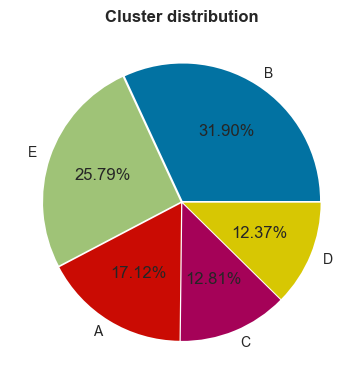

In [70]:
# Pie chart 

fig, ax = plt.subplots(ncols=1, figsize=(5, 4))
cluster_counts = df['Cluster'].value_counts()
cluster_counts.plot(kind="pie", autopct="%.2f%%", ax=ax,ylabel="",explode=([0.01] * len(cluster_counts)))
ax.set_title("Cluster distribution", fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()

Cluster B is the dominant segment, accounting for 31.90% of all credit card customers, while Cluster D is the smallest segment, representing only 12.37% of the total customer base.

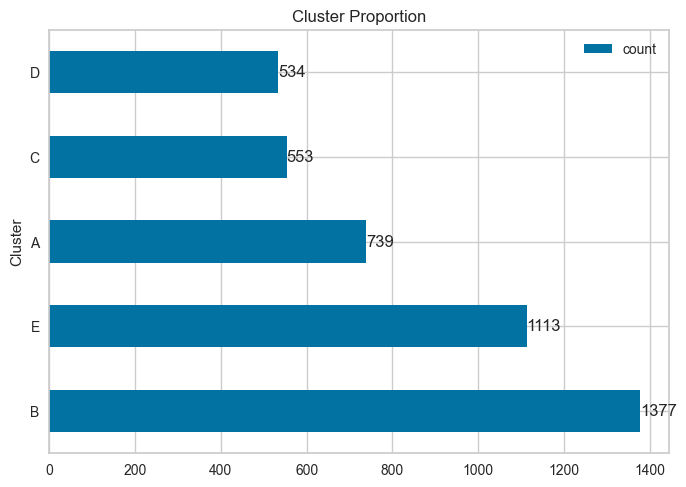

In [71]:
ax = df['Cluster'].value_counts().plot(kind='barh', legend=True, title='Cluster Proportion')

for i in ax.containers:
    ax.bar_label(i, fmt='%d')

From the results above, Cluster B has the highest number of customers at 1377, followed by Cluster E with 1113 customers. The difference between the second-to-last and last place clusters is marginal, with Cluster D having the fewest credit card customers. In summary, approximately one-third of all credit card customers at Bank Berlian belong to Cluster B.

We can now examine the characteristics of customers in each cluster based on their 'Balance', 'Purchases', 'Credit Limit', 'Payments', and 'Tenure'. This analysis provides a clearer understanding of each cluster's profile and offers valuable insights into the type of customers that belong to each segment. These insights will enable the marketing team to design more targeted offers and promotions tailored to each customer cluster.

In [72]:
# Display full columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#cluster characteristic
cols_of_interest = ['Balance', 'Purchases', 'Credit Limit', 'Payments', 'Tenure', 'Cluster', 'Full Payment Percentage']

cluster_summary = df_fe[cols_of_interest].groupby('Cluster').agg([min, max, 'median', 'mean', 'std', 'count'])
cluster_summary

Balance                                                             \
               min           max       median         mean          std count   
Cluster                                                                         
A         0.000000   2461.015559    46.461265   180.787127   319.120739   739   
B         0.488050   5693.979714  1202.869845  1407.100550   972.428084  1377   
C        78.114579  16304.889250  4593.098361  4916.487954  2666.263978   553   
D        21.311946  19043.138560  1679.905462  2525.088475  2725.711997   534   
E         0.000000   5860.433624   255.851136   689.757413   900.034028  1113   

        Purchases                                                     \
              min       max   median         mean          std count   
Cluster                                                                
A            0.00   3734.70   200.00   408.050041   562.876024   739   
B            0.00   2918.08    54.25   252.839993   405.626039  1377   
C            0.00  22101.78   117.00   466.683725  1120.234499   553   
D          777.92  49039.57  3444.13  4702.864251  4667.483624   534   
E           33.40   3173.50   738.65   903.834295   603.917372  1113   

        Credit Limit                                                   \
                 min      max  median         mean          std count   
Cluster                                                                 
A              150.0  20000.0  3000.0  3713.659600  3110.811364   739   
B              150.0  14000.0  2500.0  3000.326797  2245.948768  1377   
C             1000.0  19000.0  7500.0  7953.435805  3550.935902   553   
D              600.0  30000.0  7500.0  8199.719101  4431.846302   534   
E              300.0  18500.0  2500.0  3481.313404  2780.088708  1113   

           Payments                                                       \
                min           max       median         mean          std   
Cluster                                                                    
A          4.841543  34107.074990   545.768039  1252.224966  2192.263566   
B         14.500688   6532.686986   576.312714   816.201883   767.891782   
C        138.855523  39461.965800  2077.205644  3775.564597  4605.911064   
D        177.879919  46930.598240  3354.004609  4608.308910  4999.185051   
E         38.775803   6084.115091   759.916056   996.847560   809.826093   

              Tenure                                        \
        count    min max median       mean       std count   
Cluster                                                      
A         739      6  12   12.0  11.351827  1.514396   739   
B        1377      6  12   12.0  11.497458  1.362454  1377   
C         553      6  12   12.0  11.443038  1.444916   553   
D         534      6  12   12.0  11.889513  0.668904   534   
E        1113      6  12   12.0  11.565139  1.284078  1113   

        Full Payment Percentage                                                
                            min       max    median      mean       std count  
Cluster                                                                        
A                           0.0  1.000000  0.111111  0.298205  0.370080   739  
B                           0.0  1.000000  0.000000  0.018801  0.061858  1377  
C                           0.0  0.916667  0.000000  0.037901  0.098592   553  
D                           0.0  1.000000  0.000000  0.267312  0.371138   534  
E                           0.0  1.000000  0.083333  0.263727  0.347849  1113

Based on the results above, customers in Cluster D tend to have the highest balance, highest purchases, and highest payments among all clusters, suggesting they should be prioritized as premium customers at Bank Berlian. On the other hand, Cluster B represents the lowest priority segment due to its lowest purchases, credit limit, and payment percentage.

Customers in Cluster A, while having a relatively low account balance, tend to show moderate purchase activity and a high full payment percentage, making them a suitable target for entry-level offerings and promotions.

Lastly, tenure does not show a noticeable difference across clusters, suggesting that customers with varying tenure lengths are evenly distributed across all segments.

Next, the correlation between numerical columns and the cluster group (categorical) will be examined to identify which features have the strongest association with cluster assignment.

In [73]:
results = []
for col in num_columns:
    groups = [df_fe[df_fe['Cluster'] == c][col] for c in df_fe['Cluster'].unique()]
    f_stat, pval = f_oneway(*groups)
    results.append({'Feature': col, 'F-Statistic': f_stat, 'P-Value': pval})

anova_results = pd.DataFrame(results).sort_values('F-Statistic', ascending=False)
anova_results

,Feature,F-Statistic,P-Value
1,Balance Frequency,3037.217704,0.000000e+00
6,Purchases Frequency,2271.328448,0.000000e+00
7,Purchases Installments Frequency,1945.568391,0.000000e+00
9,Purchases Transaction,1051.244150,0.000000e+00
0,Balance,954.732761,0.000000e+00
5,Cash Advance,778.214477,0.000000e+00
2,Purchases,696.747412,0.000000e+00
8,Cash Advance Frequency,675.488655,0.000000e+00
10,Credit Limit,500.116534,0.000000e+00
4,Installments Purchases,470.490596,0.000000e+00


From the results above, all features are statistically significant (p-value < 0.05) in defining a customer's cluster type. Features with higher F-statistic values contribute more to cluster differentiation. The top 5 features are 'Balance Frequency', 'Purchases Frequency', 'Purchases Installments Frequency', 'Purchases Transaction', and 'Balance', making them the most dominant features in predicting cluster assignment. Conversely, the 5 least influential features are 'One-off Purchases', 'Payments', 'Full Payment Percentage', 'Minimum Payments', and 'Tenure'.

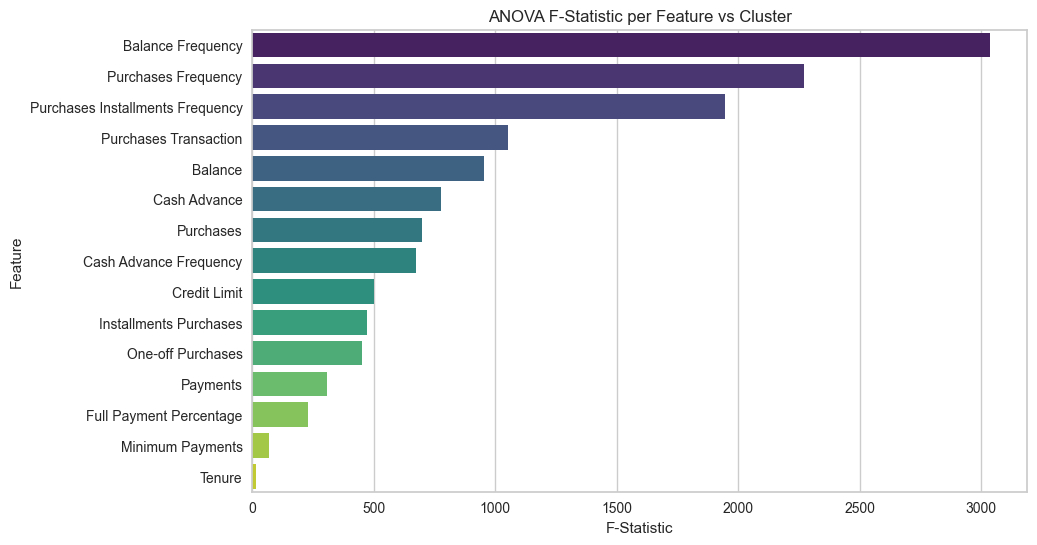

In [74]:
plt.figure(figsize=(10, 6))
sns.barplot(data=anova_results, x='F-Statistic', y='Feature', palette='viridis')
plt.title('ANOVA F-Statistic per Feature vs Cluster')
plt.xlabel('F-Statistic')
plt.ylabel('Feature')
plt.show()

The correlation of the top 5 most strongly correlated features is displayed in the figure above.

In [75]:
# Display full columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Note the trailing space in 'Purchases Transaction '
cols_strong_corr = ['Balance Frequency', 'Purchases Frequency', 'Purchases Installments Frequency', 'Purchases Transaction', 'Balance', 'Cluster'] 

cluster_summary_strong_corr = df_fe[cols_strong_corr].groupby('Cluster').agg([min, max, 'median', 'mean', 'std', 'count'])
cluster_summary_strong_corr

Balance Frequency                                                \
                      min       max    median      mean       std count   
Cluster                                                                   
A                0.000000  0.909091  0.545455  0.504816  0.198057   739   
B                0.666667  1.000000  1.000000  0.983548  0.046155  1377   
C                0.363636  1.000000  1.000000  0.970172  0.092005   553   
D                0.454545  1.000000  1.000000  0.980409  0.063468   534   
E                0.000000  1.000000  1.000000  0.967107  0.092908  1113   

        Purchases Frequency                                           \
                        min  max    median      mean       std count   
Cluster                                                                
A                  0.000000  1.0  0.250000  0.301057  0.255639   739   
B                  0.000000  1.0  0.083333  0.189085  0.242554  1377   
C                  0.000000  1.0  0.125000  0.281816  0.332785   553   
D                  0.166667  1.0  1.000000  0.927196  0.143001   534   
E                  0.333333  1.0  1.000000  0.903430  0.135698  1113   

        Purchases Installments Frequency                                      \
                                     min   max    median      mean       std   
Cluster                                                                        
A                                    0.0  1.00  0.000000  0.192828  0.243260   
B                                    0.0  0.75  0.000000  0.062509  0.135364   
C                                    0.0  1.00  0.000000  0.175777  0.286939   
D                                    0.0  1.00  0.916667  0.738082  0.329007   
E                                    0.0  1.00  0.875000  0.787209  0.254273   

              Purchases Transaction                                          \
        count                   min  max median       mean        std count   
Cluster                                                                       
A         739                     0   60    4.0   4.843031   5.209148   739   
B        1377                     0   43    1.0   3.389252   5.011713  1377   
C         553                     0   77    2.0   5.943942   8.826145   553   
D         534                     2  358   45.0  57.065543  43.203274   534   
E        1113                     0  186   15.0  19.657682  13.932280  1113   

           Balance                                                             
               min           max       median         mean          std count  
Cluster                                                                        
A         0.000000   2461.015559    46.461265   180.787127   319.120739   739  
B         0.488050   5693.979714  1202.869845  1407.100550   972.428084  1377  
C        78.114579  16304.889250  4593.098361  4916.487954  2666.263978   553  
D        21.311946  19043.138560  1679.905462  2525.088475  2725.711997   534  
E         0.000000   5860.433624   255.851136   689.757413   900.034028  1113

Based on the cluster summary table above, the following conclusions can be drawn for 
each cluster:

**Cluster A** represents low-to-moderate activity customers. They have the lowest 
balance frequency and purchase frequency among all clusters, with a low median purchase 
transaction count and relatively low account balance. These customers are infrequent 
spenders who maintain a moderate balance. They may be suitable targets for entry-level 
promotions to encourage more active credit card usage.

**Cluster B** represents low purchase, high balance frequency customers. Despite having 
the highest balance frequency (median=1), their purchase frequency and installment 
purchases are the lowest among all clusters, with minimal purchase transactions. This 
suggests that these customers primarily use their credit card to maintain a running 
balance rather than for active spending. This cluster should be the lowest priority for 
premium offerings.

**Cluster C** represents moderate activity customers. They show high balance frequency 
but low-to-moderate purchase frequency and installment purchases. Their balance and 
purchase transaction values are moderate. These customers represent a middle-ground 
segment that could be nurtured with mid-tier promotions to increase their spending 
activity.

**Cluster D** represents the highest value customers. They have the highest purchase 
frequency (median=1.0), highest installment purchase ratio (median=0.92), highest 
purchase transactions, and the highest account balance among all clusters. These 
customers are the most active and financially capable, making them the primary target 
for premium offerings, card upgrades, and exclusive perks.

**Cluster E** represents high activity customers, similar to Cluster D. They have a 
high purchase frequency (median=1.0), high installment purchase ratio (median=0.875), 
and high purchase transactions. However, their account balance is comparatively lower 
than Cluster D. These customers are strong candidates for premium promotions and 
rewards programs aimed at retaining their high spending behavior.

In summary, **Cluster D and E are the highest priority segments for premium targeting**, 
Cluster A and C have growth potential and are suitable for mid-tier and entry-level 
promotions, while Cluster B requires a different approach focused on encouraging active 
spending rather than premium offerings.

X. Model Saving

In [76]:
#model saving!
with open('pipelines.pkl','wb') as file_1:
  pickle.dump(pipelines,file_1)

with open('num_columns.txt','w') as file_2:
  json.dump(num_columns,file_2)

XI. Model Inference

The cluster prediction from the data inference is:

| Cluster Prediction: E |

As observed, the trained model has assigned the inference data to Cluster E. Based on our evaluation, customers in Cluster E are characterized by high balance frequency, purchase frequency, installment purchases, purchase transactions, and overall account balance. This profile indicates that this customer is a strong candidate for premium offerings and exclusive promotions from the marketing team.

XII. Conclusions

1. The clustering model used is K-Means, as all features in the dataset are numerical. A variance ratio of 95% was applied in PCA (Principal Component Analysis), resulting in 9 recommended components with eigenvalues of approximately 0.4. From the Elbow Method, the WCSS score was found to be well above 10,000, indicating high within-cluster variance and residuals. Based on the Silhouette Score of 0.244, the optimal number of clusters was determined to be k=5.

2. Clusters D and E represent the highest-value customers with the most active spending behavior, making them the primary targets for premium offerings, card upgrades, and exclusive perks. Cluster A and C represent customers with moderate-to-low activity and growth potential, making them suitable for entry-level and mid-tier promotions aimed at increasing their spending engagement. Cluster B, despite having a high balance frequency, shows the lowest purchase activity among all clusters and should be approached with promotions focused on encouraging active spending rather than premium offerings.

3. From the data inference, the customer has been assigned to Cluster E, which means that the customer from data inference is a highest-value customer that is suitable for the primaru target for premium offerings, card upgrades, and exclusive perks.